## Intro

### Two-GeoJSON Road Pair Matching, 2%–30% Manual Verification, and Automated Connection

This streamlined Colab notebook:

1. reads exactly two road JSON/GeoJSON files from Google Drive or uploads them into the configured Drive folder;
2. preserves the core candidate generation, feature engineering, geometric GMM, textual ECM/Beta model, and Empirical-Bayes fusion from notebook #6;
3. calculates the three model probabilities and an unsupervised optimized threshold for the combined model;
4. automatically decides confident rows;
5. sends at least 2% and at most 30% of unique candidate pairs to manual verification;
6. prioritizes uncertain base-model disagreements, then supplements with the least-confident remaining rows only when needed to reach the 2% quality-control minimum;
7. uses Section 24-compatible batch functions, Y/N buttons, keyboard Y/N input, and a contextual GIS view;
8. resolves one-to-one road conflicts, joins accepted roads at their exact shared midpoint, preserves all untouched roads and properties, and downloads two `<original_name>_updated.json` files.

No boundary file or labeled CSV is required. Plotting is limited to the interactive manual-verification view.

## 1) Install dependencies

In [ ]:
# Install only the packages required by this streamlined workflow.
%pip -q install "geopandas>=1.0" "shapely>=2.0" "pyproj>=3.6" "pyogrio>=0.9" \
    "scikit-learn>=1.5" "rapidfuzz>=3.9" "scipy>=1.12" "ipywidgets>=8.1"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.6 MB/s eta 0:00:00


## 2) Imports and configuration

In [ ]:
import os
import re
import json
import math
import shutil
import warnings
from pathlib import Path
from datetime import datetime
from typing import Optional

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point, LineString, MultiLineString, mapping
from shapely.ops import nearest_points
from rapidfuzz import fuzz
from pyproj import Transformer
from scipy.special import betaln, logsumexp
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

from IPython.display import display, clear_output, Markdown, FileLink
import ipywidgets as widgets

try:
    from google.colab import output as colab_output
    colab_output.enable_custom_widget_manager()
except Exception:
    pass

warnings.filterwarnings("ignore")

# -------------------------------------------------------------------
# User-adjustable configuration
# -------------------------------------------------------------------
BUFFER_DISTANCE_METERS = 50.0
TARGET_CRS = "EPSG:26916"  # NAD83 / UTM zone 16N; appropriate for Marion/Hamilton
LATLON_CRS = "EPSG:4326"
ROAD_ID_COL = "OBJECTID"

PCA_COLUMN_NO = 3
RANDOM_STATE = 42
GMM_MIN_COMPONENTS = 2
GMM_MAX_COMPONENTS = 6
GMM_COVARIANCE_TYPES = ["full", "diag", "tied", "spherical"]

# Manual-review barrier across all unique candidate pairs.
# The adaptive queue is never below 2% and never above 30%
# for normal production-sized candidate sets.
MIN_MANUAL_REVIEW_FRACTION = 0.02
MAX_MANUAL_REVIEW_FRACTION = 0.30
MAX_MANUAL_BATCH_SIZE = 30

# Input/output folders are separated so generated files can never be
# mistaken for new input files on a later run.
INPUT_DIR = Path("/content/road_matching_input")
OUTPUT_DIR = Path("/content/road_matching_output")
INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
MANUAL_PROGRESS_CSV = OUTPUT_DIR / "manual_review_progress.csv"
DECISION_AUDIT_CSV = OUTPUT_DIR / f"road_pair_decision_audit_{RUN_TIMESTAMP}.csv"
CONNECTION_AUDIT_CSV = OUTPUT_DIR / f"road_connection_audit_{RUN_TIMESTAMP}.csv"

print("Configuration loaded.")
print("Candidate distance:", BUFFER_DISTANCE_METERS, "meters")
print(
    "Manual-review fraction range:",
    f"{MIN_MANUAL_REVIEW_FRACTION:.0%}",
    "to",
    f"{MAX_MANUAL_REVIEW_FRACTION:.0%}",
)


Configuration loaded.
Candidate distance: 50.0 meters
Manual-review fraction range: 2% to 30%


## 3) Upload exactly two road GeoJSON files

### 3.1

In [ ]:
from pathlib import Path
import re

from google.colab import drive, files


# ---------------------------------------------------------------------------
# Google Drive configuration
# ---------------------------------------------------------------------------
DRIVE_MOUNT_POINT = Path("/content/drive")
DRIVE_GEOJSON_DIR = DRIVE_MOUNT_POINT / "MyDrive" / "geojson_files"

VALID_ROAD_EXTENSIONS = {".json", ".geojson"}


def find_road_files(folder: Path) -> list[Path]:
    """
    Return all valid JSON/GeoJSON files located directly inside the folder.

    Files inside subfolders are not included.
    """
    if not folder.is_dir():
        return []

    return sorted(
        (
            path
            for path in folder.iterdir()
            if path.is_file()
            and path.suffix.lower() in VALID_ROAD_EXTENSIONS
        ),
        key=lambda path: path.name.lower(),
    )


def county_name_from_filename(path_or_name: str | Path) -> str:
    """
    Derive a readable county/file name from a JSON/GeoJSON filename.
    """
    stem = Path(path_or_name).stem

    stem = re.sub(
        r"(_County)?_Boundary.*$",
        "",
        stem,
        flags=re.IGNORECASE,
    )

    stem = stem.strip("_ ").strip()

    if not stem:
        raise ValueError(
            f"Could not derive a readable county/file name "
            f"from {path_or_name!r}."
        )

    return stem

### 3.2

In [ ]:
# ---------------------------------------------------------------------------
# Mount Google Drive
# ---------------------------------------------------------------------------
# Colab will reuse the existing mount when Drive is already mounted.
drive.mount(
    str(DRIVE_MOUNT_POINT),
    force_remount=False,
)


# Create MyDrive/geojson_files when it does not exist.
DRIVE_GEOJSON_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------------------------
# Check whether exactly two road files already exist
# ---------------------------------------------------------------------------
saved_paths = find_road_files(DRIVE_GEOJSON_DIR)


if len(saved_paths) == 2:
    print(
        "Found exactly two road JSON/GeoJSON files in Google Drive. "
        "Using them directly."
    )

else:
    print(
        f"Google Drive folder contains {len(saved_paths)} valid road "
        "JSON/GeoJSON file(s)."
    )

    print(
        "Please upload exactly two road .json or .geojson files "
        "from your computer."
    )

    uploaded = files.upload()

    # Require exactly two uploaded files total.
    if len(uploaded) != 2:
        raise ValueError(
            f"Upload exactly two files total; received {len(uploaded)}."
        )

    # Validate filenames and extensions before modifying Google Drive.
    road_uploads = [
        (
            Path(original_name).name,
            file_bytes,
        )
        for original_name, file_bytes in uploaded.items()
        if Path(original_name).suffix.lower()
        in VALID_ROAD_EXTENSIONS
    ]

    if len(road_uploads) != 2:
        raise ValueError(
            "Both uploaded files must use the .json or .geojson "
            f"extension; received {len(road_uploads)} valid road file(s)."
        )

    # Prevent filename collisions on case-insensitive systems.
    uploaded_names_lower = [
        filename.lower()
        for filename, _ in road_uploads
    ]

    if len(set(uploaded_names_lower)) != 2:
        raise ValueError(
            "The two uploaded files must have different filenames."
        )

    # Validation succeeded.
    #
    # Remove only existing .json/.geojson files from geojson_files.
    # Other files and subfolders are left unchanged.
    for existing_path in find_road_files(DRIVE_GEOJSON_DIR):
        existing_path.unlink()

    # Save uploaded files permanently in Google Drive.
    for safe_name, file_bytes in road_uploads:
        destination = DRIVE_GEOJSON_DIR / safe_name
        destination.write_bytes(file_bytes)

    # Re-read the folder to verify that exactly two files were saved.
    saved_paths = find_road_files(DRIVE_GEOJSON_DIR)

    if len(saved_paths) != 2:
        raise RuntimeError(
            "The upload completed, but exactly two road files "
            "could not be confirmed in "
            f"{DRIVE_GEOJSON_DIR}."
        )

    print(
        "Both road files were uploaded and saved successfully to:"
    )
    print(DRIVE_GEOJSON_DIR)

Mounted at /content/drive
Found exactly two road JSON/GeoJSON files in Google Drive. Using them directly.


### 3.3

In [ ]:
# ---------------------------------------------------------------------------
# Deterministic county/file ordering
# ---------------------------------------------------------------------------
saved_paths = sorted(
    saved_paths,
    key=lambda path: path.name.lower(),
)

COUNTY_FILE_1 = str(saved_paths[0])
COUNTY_FILE_2 = str(saved_paths[1])

COUNTY_1_NAME = county_name_from_filename(COUNTY_FILE_1)
COUNTY_2_NAME = county_name_from_filename(COUNTY_FILE_2)


# ---------------------------------------------------------------------------
# Backward-compatible aliases used by the original model code
# ---------------------------------------------------------------------------
MARION_FILE = COUNTY_FILE_1
HAMILTON_FILE = COUNTY_FILE_2


# ---------------------------------------------------------------------------
# Confirmation
# ---------------------------------------------------------------------------
print()
print("Google Drive folder:", DRIVE_GEOJSON_DIR)

print()
print("County/File 1:", COUNTY_FILE_1)
print("County/File 1 name:", COUNTY_1_NAME)

print()
print("County/File 2:", COUNTY_FILE_2)
print("County/File 2 name:", COUNTY_2_NAME)

# ---------------------------------------------------------------------------
# Persistent Google Drive outputs and source-specific progress files
# ---------------------------------------------------------------------------
DRIVE_OUTPUT_DIR = (
    DRIVE_MOUNT_POINT
    / "MyDrive"
    / "road_matching_outputs"
)
DRIVE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
OUTPUT_DIR = DRIVE_OUTPUT_DIR

def _safe_run_key_part(value):
    return re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        str(value),
    ).strip("_")

PAIR_RUN_KEY = (
    f"{_safe_run_key_part(Path(COUNTY_FILE_1).stem)}"
    "__"
    f"{_safe_run_key_part(Path(COUNTY_FILE_2).stem)}"
)

MANUAL_PROGRESS_CSV = (
    OUTPUT_DIR
    / f"{PAIR_RUN_KEY}_manual_review_progress.csv"
)
SECTION_24_OUTPUT_CSV = (
    OUTPUT_DIR
    / f"{PAIR_RUN_KEY}_final_pair_decisions.csv"
)
DECISION_AUDIT_CSV = (
    OUTPUT_DIR
    / f"{PAIR_RUN_KEY}_decision_audit_{RUN_TIMESTAMP}.csv"
)
CONNECTION_AUDIT_CSV = (
    OUTPUT_DIR
    / f"{PAIR_RUN_KEY}_connection_audit_{RUN_TIMESTAMP}.csv"
)

print()
print("Persistent output folder:", OUTPUT_DIR)
print("Manual progress file:", MANUAL_PROGRESS_CSV)
print("Final decision file:", SECTION_24_OUTPUT_CSV)


Google Drive folder: /content/drive/MyDrive/geojson_files

County/File 1: /content/drive/MyDrive/geojson_files/Hamilton.json
County/File 1 name: Hamilton

County/File 2: /content/drive/MyDrive/geojson_files/Marion.json
County/File 2 name: Marion

Persistent output folder: /content/drive/MyDrive/road_matching_outputs
Manual progress file: /content/drive/MyDrive/road_matching_outputs/Hamilton__Marion_manual_review_progress.csv
Final decision file: /content/drive/MyDrive/road_matching_outputs/Hamilton__Marion_final_pair_decisions.csv


## 4) Load, validate, and project the two road datasets

In [ ]:
def ensure_crs(gdf, fallback=LATLON_CRS):
    if gdf.crs is None:
        print(f"WARNING: CRS missing; assigning fallback {fallback}.")
        gdf = gdf.set_crs(fallback)
    return gdf


def keep_line_geometries(gdf):
    valid_types = ["LineString", "MultiLineString"]
    out = gdf[gdf.geometry.notna()].copy()
    out = out[~out.geometry.is_empty].copy()
    out = out[out.geom_type.isin(valid_types)].copy()
    out.reset_index(drop=True, inplace=True)
    return out


county_1_gdf_original = gpd.read_file(COUNTY_FILE_1)
county_2_gdf_original = gpd.read_file(COUNTY_FILE_2)

for file_name, gdf in [
    (Path(COUNTY_FILE_1).name, county_1_gdf_original),
    (Path(COUNTY_FILE_2).name, county_2_gdf_original),
]:
    if ROAD_ID_COL not in gdf.columns:
        raise ValueError(
            f"{ROAD_ID_COL!r} is missing from {file_name}. "
            "Change ROAD_ID_COL in the configuration cell if another stable ID is used."
        )

county_1_gdf = keep_line_geometries(ensure_crs(county_1_gdf_original))
county_2_gdf = keep_line_geometries(ensure_crs(county_2_gdf_original))

for file_name, gdf in [
    (Path(COUNTY_FILE_1).name, county_1_gdf),
    (Path(COUNTY_FILE_2).name, county_2_gdf),
]:
    if gdf[ROAD_ID_COL].isna().any():
        raise ValueError(f"{file_name} contains missing {ROAD_ID_COL} values.")
    if gdf[ROAD_ID_COL].duplicated().any():
        duplicate_values = gdf.loc[gdf[ROAD_ID_COL].duplicated(keep=False), ROAD_ID_COL].tolist()
        raise ValueError(
            f"{file_name} contains duplicate {ROAD_ID_COL} values: {duplicate_values[:20]}"
        )

county_1_gdf = county_1_gdf.to_crs(TARGET_CRS)
county_2_gdf = county_2_gdf.to_crs(TARGET_CRS)

# Backward-compatible names required by the retained original model cells.
marion_gdf = county_1_gdf
hamilton_gdf = county_2_gdf

LATLON_TRANSFORMER = Transformer.from_crs(TARGET_CRS, LATLON_CRS, always_xy=True)

print(f"{COUNTY_1_NAME}: {len(marion_gdf)} usable road features")
print(f"{COUNTY_2_NAME}: {len(hamilton_gdf)} usable road features")
print("Projected CRS:", TARGET_CRS)


Hamilton: 24834 usable road features
Marion: 62023 usable road features
Projected CRS: EPSG:26916


## 5) Original road-preparation and candidate-generation helpers

In [ ]:
# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------

TEXT_REPLACEMENTS = {
    "STREET": "ST",
    "ROAD": "RD",
    "AVENUE": "AVE",
    "BOULEVARD": "BLVD",
    "DRIVE": "DR",
    "COURT": "CT",
    "PLACE": "PL",
    "LANE": "LN",
    "HIGHWAY": "HWY",
    "PARKWAY": "PKWY",
    "NORTH": "N",
    "SOUTH": "S",
    "EAST": "E",
    "WEST": "W",
    "COUNTY ROAD": "COUNTY ROAD",
}

LATLON_TRANSFORMER = Transformer.from_crs(TARGET_CRS, LATLON_CRS, always_xy=True)

def safe_str(v):
    if pd.isna(v):
        return ""
    return str(v).strip()

def normalize_text(v):
    s = safe_str(v).upper()
    s = s.replace(".", " ").replace(",", " ").replace("-", " ").replace("/", " ")
    s = " ".join(s.split())

    # normalize multi-token phrases first
    s = s.replace("COUNTY ROAD", "COUNTY ROAD")

    parts = [TEXT_REPLACEMENTS.get(p, p) for p in s.split()]
    return " ".join(parts)

def first_nonblank(*values):
    for v in values:
        s = safe_str(v)
        if s:
            return s
    return ""

def numeric_or_nan(v):
    if pd.isna(v) or safe_str(v) == "":
        return np.nan
    try:
        return float(v)
    except Exception:
        nums = re.findall(r"-?\d+\.?\d*", str(v))
        return float(nums[0]) if nums else np.nan

def bool_int(x):
    return int(bool(x))

def line_parts(geom):
    if geom is None or geom.is_empty:
        return []
    if geom.geom_type == "LineString":
        return [geom]
    if geom.geom_type == "MultiLineString":
        return list(geom.geoms)
    return []

def flatten_coords(geom):
    coords = []
    for part in line_parts(geom):
        coords.extend(list(part.coords))
    return coords

def vertex_count(geom):
    return len(flatten_coords(geom))

def get_lines_from_geom(geom):
    return line_parts(geom)

def get_closest_line_part_to_point(geom, point_geom):
    lines = get_lines_from_geom(geom)
    if not lines:
        return None
    return min(lines, key=lambda line: line.distance(point_geom))

def line_heading_degrees(p1, p2):
    dx = p2.x - p1.x
    dy = p2.y - p1.y
    ang = math.degrees(math.atan2(dy, dx))
    if ang < 0:
        ang += 360
    return ang

def undirected_heading_difference_deg(a, b):
    """
    Compare line orientation ignoring digitization direction.
    0 means same or reversed direction on the same axis.
    90 means orthogonal.
    """
    d = abs(a - b) % 180
    return min(d, 180 - d)

def get_local_heading_near_point(line_geom, near_point):
    line = get_closest_line_part_to_point(line_geom, near_point)
    if line is None:
        return np.nan

    coords = list(line.coords)
    if len(coords) < 2:
        return np.nan

    vertex_points = [Point(xy[:2]) for xy in coords]
    dists = [pt.distance(near_point) for pt in vertex_points]
    idx = int(np.argmin(dists))

    if idx == 0:
        p1, p2 = vertex_points[0], vertex_points[1]
    elif idx == len(vertex_points) - 1:
        p1, p2 = vertex_points[-2], vertex_points[-1]
    else:
        prev_pt = vertex_points[idx - 1]
        curr_pt = vertex_points[idx]
        next_pt = vertex_points[idx + 1]

        if curr_pt.distance(prev_pt) >= curr_pt.distance(next_pt):
            p1, p2 = prev_pt, curr_pt
        else:
            p1, p2 = curr_pt, next_pt

    return line_heading_degrees(p1, p2)

def geom_endpoints(geom):
    parts = line_parts(geom)
    if not parts:
        return (None, None)
    longest = max(parts, key=lambda g: g.length)
    coords = list(longest.coords)
    if len(coords) < 2:
        return (None, None)
    return Point(coords[0][:2]), Point(coords[-1][:2])

def interval_normalize(a, b):
    a = numeric_or_nan(a)
    b = numeric_or_nan(b)
    if np.isnan(a) or np.isnan(b):
        return (np.nan, np.nan)
    return (min(a, b), max(a, b))

def interval_overlap_score(a1, a2, b1, b2):
    a1, a2 = interval_normalize(a1, a2)
    b1, b2 = interval_normalize(b1, b2)
    if np.isnan(a1) and np.isnan(a2) and np.isnan(b1) and np.isnan(b2):
        return 0.5
    if np.isnan(a1) or np.isnan(a2) or np.isnan(b1) or np.isnan(b2):
        return 0.0

    overlap = max(0.0, min(a2, b2) - max(a1, b1))
    union = max(a2, b2) - min(a1, b1)
    if union <= 0:
        return 1.0 if a1 == b1 and a2 == b2 else 0.0
    return float(np.clip(overlap / union, 0.0, 1.0))

def midpoint_or_nan(a, b):
    a = numeric_or_nan(a)
    b = numeric_or_nan(b)
    if np.isnan(a) or np.isnan(b):
        return np.nan
    return (a + b) / 2.0

def exact_similarity(a, b, both_missing_value=0.5):
    a = normalize_text(a)
    b = normalize_text(b)
    if not a and not b:
        return both_missing_value
    if not a or not b:
        return 0.0
    return 1.0 if a == b else 0.0

def fuzzy_similarity(a, b, both_missing_value=0.5):
    a = normalize_text(a)
    b = normalize_text(b)
    if not a and not b:
        return both_missing_value
    if not a or not b:
        return 0.0
    return fuzz.token_sort_ratio(a, b) / 100.0

def speed_similarity(a, b):
    a = numeric_or_nan(a)
    b = numeric_or_nan(b)
    if np.isnan(a) and np.isnan(b):
        return 0.5
    if np.isnan(a) or np.isnan(b):
        return 0.0
    denom = max(a, b, 1.0)
    return float(np.clip(1.0 - abs(a - b) / denom, 0.0, 1.0))

def length_ratio(a, b):
    a = numeric_or_nan(a)
    b = numeric_or_nan(b)
    if np.isnan(a) and np.isnan(b):
        return 0.5
    if np.isnan(a) or np.isnan(b) or a <= 0 or b <= 0:
        return 0.0
    return float(min(a, b) / max(a, b))

def point_to_latlon_triplet(point):
    if point is None or point.is_empty:
        return [None, None, None]
    x, y = point.x, point.y
    lon, lat = LATLON_TRANSFORMER.transform(x, y)
    z = getattr(point, "z", 0.0) if getattr(point, "has_z", False) else 0.0
    return [round(lon, 8), round(lat, 8), float(z)]

def connecting_nodes_json(left_point, right_point):
    return json.dumps([point_to_latlon_triplet(left_point), point_to_latlon_triplet(right_point)])

def choose_best(col_names, preferred, fallback):
    for c in preferred:
        if c in col_names:
            return c
    for c in fallback:
        if c in col_names:
            return c
    return None

def road_type_from_parts(pretype, posttype):
    parts = [normalize_text(pretype), normalize_text(posttype)]
    parts = [p for p in parts if p]
    return " ".join(parts).strip()

def build_full_road_label(predir, pretype, street_name, posttype, postdir):
    parts = [
        normalize_text(predir),
        normalize_text(pretype),
        normalize_text(street_name),
        normalize_text(posttype),
        normalize_text(postdir),
    ]
    return " ".join([p for p in parts if p]).strip()

def extract_prepared_road_columns(gdf):
    out = gdf.copy()
    cols = set(out.columns)

    out["predir"] = out.apply(
        lambda r: normalize_text(first_nonblank(r.get("st_predir", ""), r.get("geopredir", ""))),
        axis=1
    )
    out["pretype"] = out.apply(
        lambda r: normalize_text(first_nonblank(r.get("st_pretyp", ""), r.get("geopretype", ""))),
        axis=1
    )
    out["street_name"] = out.apply(
        lambda r: normalize_text(first_nonblank(r.get("st_name", ""), r.get("geostreetname", ""), r.get("lst_name", ""))),
        axis=1
    )
    out["posttype"] = out.apply(
        lambda r: normalize_text(first_nonblank(r.get("st_postyp", ""), r.get("geostreettype", ""), r.get("lst_typ", ""))),
        axis=1
    )
    out["postdir"] = out.apply(
        lambda r: normalize_text(first_nonblank(r.get("st_postdir", ""), r.get("st_posdir", ""), r.get("geosufdir", ""), r.get("lst_posdir", ""))),
        axis=1
    )

    out["road_name"] = out["street_name"]
    out["road_type"] = out.apply(lambda r: road_type_from_parts(r["pretype"], r["posttype"]), axis=1)
    out["full_road_label"] = out.apply(
        lambda r: build_full_road_label(
            r["predir"], r["pretype"], r["street_name"], r["posttype"], r["postdir"]
        ),
        axis=1
    )

    # Fallback if the decomposed label is empty.
    out["full_road_label"] = out.apply(
        lambda r: r["full_road_label"] if r["full_road_label"] else normalize_text(first_nonblank(r.get("geofulladdress", ""), r.get("geofulladd", ""))),
        axis=1
    )

    out["roadclass_norm"] = out["roadclass"].apply(normalize_text) if "roadclass" in out.columns else ""
    out["oneway_norm"] = out["oneway"].apply(normalize_text) if "oneway" in out.columns else ""
    out["speedlimit_num"] = out["speedlimit"].apply(numeric_or_nan) if "speedlimit" in out.columns else np.nan

    out["from_left"] = out.apply(lambda r: numeric_or_nan(first_nonblank(r.get("geofromleft", ""), r.get("fromaddr_l", ""))), axis=1)
    out["to_left"] = out.apply(lambda r: numeric_or_nan(first_nonblank(r.get("geotoleft", ""), r.get("toaddr_l", ""))), axis=1)
    out["from_right"] = out.apply(lambda r: numeric_or_nan(first_nonblank(r.get("geofromright", ""), r.get("fromaddr_r", ""))), axis=1)
    out["to_right"] = out.apply(lambda r: numeric_or_nan(first_nonblank(r.get("geotoright", ""), r.get("toaddr_r", ""))), axis=1)

    out["addr_range_mid_left"] = out.apply(lambda r: midpoint_or_nan(r["from_left"], r["to_left"]), axis=1)
    out["addr_range_mid_right"] = out.apply(lambda r: midpoint_or_nan(r["from_right"], r["to_right"]), axis=1)

    out["parity_left"] = out.apply(lambda r: normalize_text(first_nonblank(r.get("geoparityleft", ""), r.get("parity_l", ""))), axis=1)
    out["parity_right"] = out.apply(lambda r: normalize_text(first_nonblank(r.get("geoparityright", ""), r.get("parity_r", ""))), axis=1)

    out["city_left"] = out.apply(lambda r: normalize_text(first_nonblank(r.get("geocityleft", ""), r.get("postcomm_l", ""), r.get("msagcomm_l", ""))), axis=1)
    out["city_right"] = out.apply(lambda r: normalize_text(first_nonblank(r.get("geocityright", ""), r.get("postcomm_r", ""), r.get("msagcomm_r", ""))), axis=1)
    out["zip_left"] = out.apply(lambda r: normalize_text(first_nonblank(r.get("geozipl", ""), r.get("postcode_l", ""), r.get("esri_zipl", ""))), axis=1)
    out["zip_right"] = out.apply(lambda r: normalize_text(first_nonblank(r.get("geozipr", ""), r.get("postcode_r", ""), r.get("esri_zipr", ""))), axis=1)

    out["geom_length_m"] = out.geometry.length.astype(float)
    out["vertex_count"] = out.geometry.apply(vertex_count).astype(int)
    out["is_multilinestring"] = (out.geom_type == "MultiLineString").astype(int)

    # Backward-compatible field for older logic / quick review.
    out["match_name"] = out["full_road_label"]

    return out

def find_candidate_pairs(left_gdf, right_gdf, search_distance_m=40.0):
    """
    Direct line-to-line candidate generation without using any boundary file.
    For each road in the first county file, find roads in the second county file whose
    geometries are within BUFFER_DISTANCE_METERS.
    """
    right_sindex = right_gdf.sindex
    pairs = []

    for left_idx, left_row in left_gdf.iterrows():
        left_geom = left_row.geometry
        if left_geom is None or left_geom.is_empty:
            continue

        bounds = left_geom.buffer(search_distance_m).bounds
        candidate_positions = list(right_sindex.intersection(bounds))

        if not candidate_positions:
            continue

        for pos in candidate_positions:
            right_idx = right_gdf.index[pos]
            right_row = right_gdf.loc[right_idx]
            right_geom = right_row.geometry

            if right_geom is None or right_geom.is_empty:
                continue

            distance_m = float(left_geom.distance(right_geom))
            if distance_m > search_distance_m:
                continue

            p_left, p_right = nearest_points(left_geom, right_geom)
            left_start, left_end = geom_endpoints(left_geom)
            right_start, right_end = geom_endpoints(right_geom)

            endpoint_dists = []
            for a in [left_start, left_end]:
                for b in [right_start, right_end]:
                    if a is not None and b is not None:
                        endpoint_dists.append(a.distance(b))
            best_endpoint_gap = float(min(endpoint_dists)) if endpoint_dists else np.nan

            pairs.append({
                "m_idx": left_idx,
                "h_idx": right_idx,
                "distance_m": distance_m,
                "county_1_contact_point": p_left,
                "county_2_contact_point": p_right,
                "contact_midpoint": Point(
                    (p_left.x + p_right.x) / 2.0,
                    (p_left.y + p_right.y) / 2.0
                ),
                "start_to_start_dist": left_start.distance(right_start) if left_start is not None and right_start is not None else np.nan,
                "start_to_end_dist": left_start.distance(right_end) if left_start is not None and right_end is not None else np.nan,
                "end_to_start_dist": left_end.distance(right_start) if left_end is not None and right_start is not None else np.nan,
                "end_to_end_dist": left_end.distance(right_end) if left_end is not None and right_end is not None else np.nan,
                "best_endpoint_gap": best_endpoint_gap,
            })

    return pd.DataFrame(pairs)

def normalize_distance_score(dist_m, buffer_distance_m):
    if pd.isna(dist_m):
        return 0.0
    return float(np.clip(1.0 - float(dist_m) / float(buffer_distance_m), 0.0, 1.0))

def safe_export_df(df):
    """
    Convert geometry-like objects to WKT / JSON strings so the frame can be written cleanly to CSV.
    """
    out = df.copy()
    for col in out.columns:
        sample_non_null = None
        for v in out[col]:
            if v is not None and not (isinstance(v, float) and np.isnan(v)):
                sample_non_null = v
                break

        if sample_non_null is None:
            continue

        if hasattr(sample_non_null, "wkt"):
            out[col] = out[col].apply(lambda g: None if g is None else g.wkt)
    return out

def fit_best_gmm_by_bic(X, min_components=2, max_components=6, covariance_types=None, random_state=42):
    if covariance_types is None:
        covariance_types = ["full", "diag", "tied", "spherical"]

    n_samples = X.shape[0]
    if n_samples < 2:
        return None, {"reason": "fewer than 2 samples"}

    upper = int(min(max_components, n_samples))
    lower = int(min_components)

    if upper < lower:
        return None, {"reason": "not enough samples for requested component range"}

    best_model = None
    best_meta = None

    for n_components in range(lower, upper + 1):
        for cov_type in covariance_types:
            try:
                model = GaussianMixture(
                    n_components=n_components,
                    covariance_type=cov_type,
                    n_init=5,
                    random_state=random_state,
                    reg_covar=1e-6,
                )
                model.fit(X)
                bic = model.bic(X)

                if best_model is None or bic < best_meta["bic"]:
                    best_model = model
                    best_meta = {
                        "bic": bic,
                        "n_components": n_components,
                        "covariance_type": cov_type,
                    }
            except Exception:
                continue

    return best_model, best_meta

def orient_pc1_positive(pca_df, anchor_series):
    out = pca_df.copy()
    if out.empty or "pca_1" not in out.columns:
        return out

    anchor = pd.Series(anchor_series).astype(float)
    if anchor.nunique(dropna=True) <= 1:
        return out

    corr = np.corrcoef(out["pca_1"], anchor)[0, 1]
    if pd.notna(corr) and corr < 0:
        out["pca_1"] = -1.0 * out["pca_1"]
    return out

## 6) Prepare roads and generate candidate pairs

In [ ]:
# Prepare the original road attributes used by both base models.
marion_match = extract_prepared_road_columns(marion_gdf)
hamilton_match = extract_prepared_road_columns(hamilton_gdf)

# Generate direct road-to-road candidates within BUFFER_DISTANCE_METERS.
possible_couples_df = find_candidate_pairs(
    marion_match,
    hamilton_match,
    search_distance_m=BUFFER_DISTANCE_METERS,
)

if possible_couples_df.empty:
    raise ValueError(
        "No candidate pairs were found. Increase BUFFER_DISTANCE_METERS only if appropriate."
    )

possible_couples_df = possible_couples_df.merge(
    marion_match.reset_index().rename(columns={"index": "m_idx"}),
    on="m_idx",
    how="left",
)

possible_couples_df = possible_couples_df.merge(
    hamilton_match.reset_index().rename(columns={"index": "h_idx"}),
    on="h_idx",
    how="left",
    suffixes=("_county1", "_county2"),
)

print("Candidate pairs:", len(possible_couples_df))


Candidate pairs: 2264


## 7) Original feature engineering

In [ ]:
# -------------------------------------------------------------------
# Feature engineering
# -------------------------------------------------------------------
features_df = possible_couples_df.copy()

features_df["County_1"] = COUNTY_1_NAME
features_df["County_2"] = COUNTY_2_NAME

features_df["county_1_road_id"] = features_df[f"{ROAD_ID_COL}_county1"]
features_df["county_2_road_id"] = features_df[f"{ROAD_ID_COL}_county2"]

# Human-readable metadata only (not used in ML)
features_df["connecting_nodes"] = features_df.apply(
    lambda r: connecting_nodes_json(r["county_1_contact_point"], r["county_2_contact_point"]),
    axis=1
)

# Backward-compatible compact names
features_df["name_1"] = features_df["full_road_label_county1"]
features_df["name_2"] = features_df["full_road_label_county2"]

# Heading / orientation
features_df["heading_deg_1"] = features_df.apply(
    lambda r: get_local_heading_near_point(r["geometry_county1"], r["county_1_contact_point"]),
    axis=1
)
features_df["heading_deg_2"] = features_df.apply(
    lambda r: get_local_heading_near_point(r["geometry_county2"], r["county_2_contact_point"]),
    axis=1
)
features_df["heading_diff_deg"] = features_df.apply(
    lambda r: undirected_heading_difference_deg(r["heading_deg_1"], r["heading_deg_2"])
    if pd.notna(r["heading_deg_1"]) and pd.notna(r["heading_deg_2"])
    else 90.0,
    axis=1
)

# Pairwise normalized scores
features_df["distance_score"] = features_df["distance_m"].apply(
    lambda d: normalize_distance_score(d, BUFFER_DISTANCE_METERS)
)
features_df["endpoint_gap_score"] = features_df["best_endpoint_gap"].apply(
    lambda d: normalize_distance_score(d, BUFFER_DISTANCE_METERS)
)

features_df["heading_score"] = (
    1.0 - (features_df["heading_diff_deg"] / 90.0)
).clip(0.0, 1.0)

features_df["road_name_score"] = features_df.apply(
    lambda r: fuzzy_similarity(r["road_name_county1"], r["road_name_county2"]),
    axis=1
)
features_df["road_type_score"] = features_df.apply(
    lambda r: exact_similarity(r["road_type_county1"], r["road_type_county2"]),
    axis=1
)
features_df["predir_score"] = features_df.apply(
    lambda r: exact_similarity(r["predir_county1"], r["predir_county2"]),
    axis=1
)
features_df["pretype_score"] = features_df.apply(
    lambda r: exact_similarity(r["pretype_county1"], r["pretype_county2"]),
    axis=1
)
features_df["postdir_score"] = features_df.apply(
    lambda r: exact_similarity(r["postdir_county1"], r["postdir_county2"]),
    axis=1
)
features_df["full_road_label_score"] = features_df.apply(
    lambda r: fuzzy_similarity(r["full_road_label_county1"], r["full_road_label_county2"]),
    axis=1
)

features_df["roadclass_score"] = features_df.apply(
    lambda r: exact_similarity(r["roadclass_norm_county1"], r["roadclass_norm_county2"]),
    axis=1
)
features_df["oneway_score"] = features_df.apply(
    lambda r: exact_similarity(r["oneway_norm_county1"], r["oneway_norm_county2"]),
    axis=1
)
features_df["speed_score"] = features_df.apply(
    lambda r: speed_similarity(r["speedlimit_num_county1"], r["speedlimit_num_county2"]),
    axis=1
)

features_df["left_parity_score"] = features_df.apply(
    lambda r: exact_similarity(r["parity_left_county1"], r["parity_left_county2"]),
    axis=1
)
features_df["right_parity_score"] = features_df.apply(
    lambda r: exact_similarity(r["parity_right_county1"], r["parity_right_county2"]),
    axis=1
)
features_df["parity_score"] = features_df[["left_parity_score", "right_parity_score"]].mean(axis=1)

features_df["left_range_overlap_score"] = features_df.apply(
    lambda r: interval_overlap_score(
        r["from_left_county1"], r["to_left_county1"],
        r["from_left_county2"], r["to_left_county2"]
    ),
    axis=1
)
features_df["right_range_overlap_score"] = features_df.apply(
    lambda r: interval_overlap_score(
        r["from_right_county1"], r["to_right_county1"],
        r["from_right_county2"], r["to_right_county2"]
    ),
    axis=1
)
features_df["address_range_score"] = features_df[
    ["left_range_overlap_score", "right_range_overlap_score"]
].mean(axis=1)

features_df["geom_length_diff_m"] = (
    features_df["geom_length_m_county1"] - features_df["geom_length_m_county2"]
).abs()
features_df["geom_length_ratio"] = features_df.apply(
    lambda r: length_ratio(r["geom_length_m_county1"], r["geom_length_m_county2"]),
    axis=1
)
features_df["length_score"] = features_df["geom_length_ratio"]

# Optional context features (kept available for downstream analysis / ablation)
features_df["city_left_score"] = features_df.apply(
    lambda r: exact_similarity(r["city_left_county1"], r["city_left_county2"]),
    axis=1
)
features_df["city_right_score"] = features_df.apply(
    lambda r: exact_similarity(r["city_right_county1"], r["city_right_county2"]),
    axis=1
)
features_df["zip_left_score"] = features_df.apply(
    lambda r: exact_similarity(r["zip_left_county1"], r["zip_left_county2"]),
    axis=1
)
features_df["zip_right_score"] = features_df.apply(
    lambda r: exact_similarity(r["zip_right_county1"], r["zip_right_county2"]),
    axis=1
)
features_df["municipality_score"] = features_df[
    ["city_left_score", "city_right_score", "zip_left_score", "zip_right_score"]
].mean(axis=1)

## 8) Original geometric/textual feature split

In [ ]:
# -------------------------------------------------------------------
# Split the normalized feature space into two groups:
#   1) Geometric properties
#   2) Taxonomy / textual properties
#
# Important design note:
# - Section 11 remains unchanged.
# - To keep the split clean from section 12 onward, we explicitly
#   separate city-context and ZIP-context here using the already
#   engineered normalized columns from section 11.
# -------------------------------------------------------------------

# Clean split helpers built from section-11 outputs
features_df["municipality_score"] = features_df[
    ["city_left_score", "city_right_score"]
].mean(axis=1)

features_df["zip_score"] = features_df[
    ["zip_left_score", "zip_right_score"]
].mean(axis=1)

GEOMETRIC_FEATURE_COLS = [
    "distance_score",
    "endpoint_gap_score",
    "heading_score",
    "oneway_score",
    "speed_score",
    "parity_score",
    "left_range_overlap_score",
    "right_range_overlap_score",
    "address_range_score",
    "length_score",
    "municipality_score",
]

TEXTUAL_FEATURE_COLS = [
    "road_name_score",
    "road_type_score",
    "roadclass_score",
    "predir_score",
    "pretype_score",
    "postdir_score",
    "full_road_label_score",
    "zip_score",
]

missing_geometric_cols = [c for c in GEOMETRIC_FEATURE_COLS if c not in features_df.columns]
missing_textual_cols = [c for c in TEXTUAL_FEATURE_COLS if c not in features_df.columns]

if missing_geometric_cols:
    raise ValueError(f"Missing geometric feature columns: {missing_geometric_cols}")
if missing_textual_cols:
    raise ValueError(f"Missing textual feature columns: {missing_textual_cols}")

COMMON_ID_COLS = [
    "County_1",
    "county_1_road_id",
    "County_2",
    "county_2_road_id",
    "connecting_nodes",
]

GEOMETRIC_METADATA_COLS = [
    "distance_m",
    "best_endpoint_gap",
    "heading_deg_1",
    "heading_deg_2",
    "heading_diff_deg",
    "geom_length_diff_m",
    "geom_length_ratio",
    "city_left_score",
    "city_right_score",
]

TEXTUAL_METADATA_COLS = [
    "road_name_county1",
    "road_name_county2",
    "road_type_county1",
    "road_type_county2",
    "predir_county1",
    "predir_county2",
    "pretype_county1",
    "pretype_county2",
    "postdir_county1",
    "postdir_county2",
    "full_road_label_county1",
    "full_road_label_county2",
    "zip_left_county1",
    "zip_left_county2",
    "zip_right_county1",
    "zip_right_county2",
    "zip_left_score",
    "zip_right_score",
]

geometric_features_df = features_df[
    COMMON_ID_COLS + GEOMETRIC_METADATA_COLS + GEOMETRIC_FEATURE_COLS
].copy()

textual_features_df = features_df[
    COMMON_ID_COLS + TEXTUAL_METADATA_COLS + TEXTUAL_FEATURE_COLS
].copy()

## 9) Original fixed two-cluster GMM helper

In [ ]:
# -------------------------------------------------------------------
# 13) Helper for fixed 2-cluster GaussianMixture scoring
#
# Updated purpose:
#   Keep the same public output columns used by later sections, but allow
#   Section #14 to provide a stronger "validity anchor" for geometric cases.
#
# Why this is safe:
#   Later sections still receive:
#     geometric_valid_pair_probability
#     geometric_invalid_pair_probability
#     geometric_is_valid_pair
#     geometric_confidence_score
# -------------------------------------------------------------------

def _clip01_series(values):
    return pd.to_numeric(values, errors="coerce").fillna(0.0).clip(0.0, 1.0)


def _dedupe_keep_order(items):
    seen = set()
    out = []
    for item in items:
        if item not in seen:
            seen.add(item)
            out.append(item)
    return out


def run_fixed_two_cluster_gmm(
    base_df,
    feature_cols,
    prefix,
    random_state=42,
    fill_value=0.5,
    covariance_try_order=("full", "diag", "tied", "spherical"),
    validity_anchor_col=None,
    positive_anchor_cols=None,
    negative_anchor_cols=None,
    feature_weight_map=None,
):
    """
    Fit a fixed 2-cluster GaussianMixture on selected feature columns.

    Cluster meaning is assigned after fitting:
      - valid cluster   = cluster with higher validity anchor
      - invalid cluster = the other cluster

    Backward compatible:
      If no validity_anchor_col is provided, this behaves like the old helper
      and uses the mean of the model input columns as the quality anchor.
    """
    if len(feature_cols) == 0:
        raise ValueError(f"{prefix}: feature_cols cannot be empty")

    feature_cols = _dedupe_keep_order(list(feature_cols))

    missing_cols = [c for c in feature_cols if c not in base_df.columns]
    if missing_cols:
        raise ValueError(f"{prefix}: missing feature columns: {missing_cols}")

    model_input_df = base_df[feature_cols].copy()

    for col in feature_cols:
        model_input_df[col] = pd.to_numeric(model_input_df[col], errors="coerce")

    model_input_df = model_input_df.fillna(fill_value).clip(0.0, 1.0)
    X = model_input_df.values

    if X.shape[0] < 2:
        raise ValueError(f"{prefix}: need at least 2 rows for a 2-cluster GMM")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    if feature_weight_map is not None:
        weights = np.array(
            [float(feature_weight_map.get(col, 1.0)) for col in feature_cols],
            dtype=float,
        )
        weights = np.where(np.isfinite(weights), weights, 1.0)
        weights = np.maximum(weights, 0.01)
        X_scaled = X_scaled * weights.reshape(1, -1)

    fitted_model = None
    used_covariance_type = None
    fit_error_messages = []

    for cov_type in covariance_try_order:
        try:
            candidate_model = GaussianMixture(
                n_components=2,
                covariance_type=cov_type,
                n_init=10,
                random_state=random_state,
                reg_covar=1e-6,
            )
            candidate_model.fit(X_scaled)
            fitted_model = candidate_model
            used_covariance_type = cov_type
            break
        except Exception as e:
            fit_error_messages.append(f"{cov_type}: {e}")

    if fitted_model is None:
        raise RuntimeError(
            f"{prefix}: could not fit a 2-cluster GMM. Errors: {fit_error_messages}"
        )

    cluster_labels = fitted_model.predict(X_scaled)
    cluster_proba = fitted_model.predict_proba(X_scaled)

    if validity_anchor_col is not None and validity_anchor_col in base_df.columns:
        quality_anchor = _clip01_series(base_df[validity_anchor_col])
        anchor_source = validity_anchor_col

    elif positive_anchor_cols is not None or negative_anchor_cols is not None:
        positive_anchor_cols = [
            c for c in (positive_anchor_cols or []) if c in model_input_df.columns
        ]
        negative_anchor_cols = [
            c for c in (negative_anchor_cols or []) if c in model_input_df.columns
        ]

        if positive_anchor_cols:
            positive_anchor = model_input_df[positive_anchor_cols].mean(axis=1)
        else:
            positive_anchor = pd.Series(0.5, index=model_input_df.index)

        if negative_anchor_cols:
            negative_anchor = model_input_df[negative_anchor_cols].mean(axis=1)
        else:
            negative_anchor = pd.Series(0.0, index=model_input_df.index)

        quality_anchor = (positive_anchor * (1.0 - negative_anchor)).clip(0.0, 1.0)
        anchor_source = "positive_minus_negative_anchor"

    else:
        quality_anchor = model_input_df.mean(axis=1).clip(0.0, 1.0)
        anchor_source = "mean_of_model_features"

    cluster_quality = (
        pd.DataFrame({
            "cluster_label": cluster_labels,
            "quality_anchor": quality_anchor,
        })
        .groupby("cluster_label", as_index=False)["quality_anchor"]
        .mean()
        .sort_values("quality_anchor", ascending=False)
        .reset_index(drop=True)
    )

    valid_cluster = int(cluster_quality.loc[0, "cluster_label"])
    invalid_cluster = int([c for c in range(2) if c != valid_cluster][0])

    updated_df = base_df.copy()
    updated_df[f"{prefix}_cluster_label"] = cluster_labels
    updated_df[f"{prefix}_quality_anchor"] = quality_anchor
    updated_df[f"{prefix}_valid_cluster"] = valid_cluster
    updated_df[f"{prefix}_invalid_cluster"] = invalid_cluster
    updated_df[f"{prefix}_valid_pair_probability"] = cluster_proba[:, valid_cluster]
    updated_df[f"{prefix}_invalid_pair_probability"] = cluster_proba[:, invalid_cluster]
    updated_df[f"{prefix}_is_valid_pair"] = (
        updated_df[f"{prefix}_valid_pair_probability"]
        >= updated_df[f"{prefix}_invalid_pair_probability"]
    )
    updated_df[f"{prefix}_confidence_score"] = updated_df[f"{prefix}_valid_pair_probability"]

    cluster_summary_df = (
        updated_df
        .groupby(f"{prefix}_cluster_label")
        .agg(
            row_count=(f"{prefix}_cluster_label", "size"),
            mean_quality_anchor=(f"{prefix}_quality_anchor", "mean"),
            mean_valid_pair_probability=(f"{prefix}_valid_pair_probability", "mean"),
            mean_invalid_pair_probability=(f"{prefix}_invalid_pair_probability", "mean"),
        )
        .reset_index()
        .sort_values("mean_quality_anchor", ascending=False)
        .reset_index(drop=True)
    )

    feature_means_by_cluster = (
        model_input_df
        .assign(**{f"{prefix}_cluster_label": cluster_labels})
        .groupby(f"{prefix}_cluster_label")[feature_cols]
        .mean()
        .reset_index()
    )

    cluster_summary_df = cluster_summary_df.merge(
        feature_means_by_cluster,
        on=f"{prefix}_cluster_label",
        how="left",
    )

    model_meta = {
        "prefix": prefix,
        "covariance_type": used_covariance_type,
        "n_components": 2,
        "valid_cluster": valid_cluster,
        "invalid_cluster": invalid_cluster,
        "feature_cols": feature_cols,
        "anchor_source": anchor_source,
        "feature_weight_map": feature_weight_map or {},
    }

    return updated_df, model_input_df, cluster_summary_df, model_meta

## 10) Original geometric model

In [ ]:
# -------------------------------------------------------------------
# 14) Run GaussianMixture on geometric properties
#
# Updated purpose:
#   Keep Sections #15 onward compatible, while improving geometric scoring
#   for the valid/invalid patterns observed in the visual review:
#
#   Valid examples to reward:
#     - same-road continuation / near overlap
#     - perpendicular T-junction / intersection
#     - endpoint-to-line connection
#     - curved or roundabout connection when there is real geometry contact
#
#   Invalid examples to penalize:
#     - close but disconnected
#     - parallel but separated
#     - nearby roundabout/ramp arcs with no real connection
#     - local/cul-de-sac roads near a main road but not connected
#
# Important:
#   This section creates extra geometric columns inside Section #14 only.
#   Existing public output columns are preserved:
#     geometric_valid_pair_probability
#     geometric_invalid_pair_probability
#     geometric_is_valid_pair
#     geometric_confidence_score
# -------------------------------------------------------------------

# ============================================================
# 14.1) Tunable geometry thresholds
# ============================================================

SECTION_14_ENDPOINT_TO_LINE_TOLERANCE_M = 60.0
SECTION_14_TIGHT_CONNECTION_TOLERANCE_M = 30.0
SECTION_14_CORRIDOR_BUFFER_M = 8.0

SECTION_14_RULE_WEIGHT = 0.70
SECTION_14_GMM_WEIGHT = 0.30


# ============================================================
# 14.2) Geometry helper functions
# ============================================================

def _section_14_clip01(value):
    try:
        if pd.isna(value):
            return 0.0
        return float(np.clip(float(value), 0.0, 1.0))
    except Exception:
        return 0.0


def _section_14_linear_distance_score(distance_m, tolerance_m):
    """
    1 at 0 meters, linearly decreases to 0 at tolerance_m.
    """
    try:
        if pd.isna(distance_m):
            return 0.0
        distance_m = float(distance_m)
        tolerance_m = float(tolerance_m)
        if tolerance_m <= 0:
            return 0.0
        return float(np.clip(1.0 - distance_m / tolerance_m, 0.0, 1.0))
    except Exception:
        return 0.0


def _section_14_gaussian_distance_score(distance_m, sigma_m):
    """
    Smooth distance score. Useful for near-contact tolerance.
    """
    try:
        if pd.isna(distance_m):
            return 0.0
        distance_m = float(distance_m)
        sigma_m = float(sigma_m)
        if sigma_m <= 0:
            return 0.0
        return float(np.exp(-1.0 * (distance_m / sigma_m) ** 2))
    except Exception:
        return 0.0


def _section_14_line_parts(geom):
    if geom is None:
        return []
    try:
        if geom.is_empty:
            return []
        if geom.geom_type == "LineString":
            return [geom]
        if geom.geom_type == "MultiLineString":
            return list(geom.geoms)
    except Exception:
        return []
    return []


def _section_14_endpoints_all_parts(geom):
    points = []
    for line in _section_14_line_parts(geom):
        try:
            coords = list(line.coords)
            if len(coords) >= 2:
                points.append(Point(coords[0][:2]))
                points.append(Point(coords[-1][:2]))
        except Exception:
            continue
    return points


def _section_14_min_endpoint_to_line_distance(geom1, geom2):
    """
    Minimum distance from any endpoint of one geometry to the other line geometry.
    This is the key fix for T-junction and endpoint-to-middle connections.
    """
    distances = []

    endpoints_1 = _section_14_endpoints_all_parts(geom1)
    endpoints_2 = _section_14_endpoints_all_parts(geom2)

    for pt in endpoints_1:
        try:
            distances.append(float(pt.distance(geom2)))
        except Exception:
            pass

    for pt in endpoints_2:
        try:
            distances.append(float(pt.distance(geom1)))
        except Exception:
            pass

    if not distances:
        return np.nan

    return float(np.nanmin(distances))


def _section_14_corridor_overlap_score(geom1, geom2, buffer_m=8.0):
    """
    Approximate same-corridor / near-overlap score using buffered centerlines.
    This helps reward true same-road continuation while keeping separated roads low.
    """
    try:
        if geom1 is None or geom2 is None or geom1.is_empty or geom2.is_empty:
            return 0.0

        b1 = geom1.buffer(buffer_m)
        b2 = geom2.buffer(buffer_m)

        denom = min(float(b1.area), float(b2.area))
        if denom <= 0:
            return 0.0

        return float(np.clip(b1.intersection(b2).area / denom, 0.0, 1.0))
    except Exception:
        return 0.0


def _section_14_pair_geometry_stats(row):
    geom1 = row.get("geometry_county1", None)
    geom2 = row.get("geometry_county2", None)

    stats = {
        "line_to_line_distance_geometry_m": np.nan,
        "geometry_intersects_flag": 0.0,
        "geometry_touches_flag": 0.0,
        "geometry_crosses_flag": 0.0,
        "geometry_overlaps_flag": 0.0,
        "endpoint_to_line_min_m": np.nan,
        "corridor_overlap_score": 0.0,
    }

    if geom1 is None or geom2 is None:
        return pd.Series(stats)

    try:
        if geom1.is_empty or geom2.is_empty:
            return pd.Series(stats)
    except Exception:
        return pd.Series(stats)

    try:
        stats["line_to_line_distance_geometry_m"] = float(geom1.distance(geom2))
    except Exception:
        pass

    try:
        stats["geometry_intersects_flag"] = 1.0 if geom1.intersects(geom2) else 0.0
    except Exception:
        pass

    try:
        stats["geometry_touches_flag"] = 1.0 if geom1.touches(geom2) else 0.0
    except Exception:
        pass

    try:
        stats["geometry_crosses_flag"] = 1.0 if geom1.crosses(geom2) else 0.0
    except Exception:
        pass

    try:
        stats["geometry_overlaps_flag"] = 1.0 if geom1.overlaps(geom2) else 0.0
    except Exception:
        pass

    stats["endpoint_to_line_min_m"] = _section_14_min_endpoint_to_line_distance(
        geom1,
        geom2,
    )

    stats["corridor_overlap_score"] = _section_14_corridor_overlap_score(
        geom1,
        geom2,
        buffer_m=SECTION_14_CORRIDOR_BUFFER_M,
    )

    return pd.Series(stats)


# ============================================================
# 14.3) Build connection-pattern features
# ============================================================

geometry_stats_df = features_df.apply(
    _section_14_pair_geometry_stats,
    axis=1,
)

for col in geometry_stats_df.columns:
    features_df[col] = geometry_stats_df[col]

features_df["line_to_line_distance_m"] = pd.to_numeric(
    features_df.get("distance_m", np.nan),
    errors="coerce",
)

features_df["line_to_line_distance_m"] = features_df["line_to_line_distance_m"].fillna(
    pd.to_numeric(
        features_df["line_to_line_distance_geometry_m"],
        errors="coerce",
    )
)

features_df["heading_diff_deg"] = pd.to_numeric(
    features_df["heading_diff_deg"],
    errors="coerce",
).fillna(90.0).clip(0.0, 90.0)

if "heading_score_original" not in features_df.columns:
    features_df["heading_score_original"] = pd.to_numeric(
        features_df.get("heading_score", np.nan),
        errors="coerce",
    ).fillna(0.0).clip(0.0, 1.0)

features_df["parallel_heading_score"] = (
    1.0 - features_df["heading_diff_deg"] / 90.0
).clip(0.0, 1.0)

features_df["perpendicular_heading_score"] = (
    features_df["heading_diff_deg"] / 90.0
).clip(0.0, 1.0)

features_df["line_to_line_distance_score"] = features_df["line_to_line_distance_m"].apply(
    lambda d: _section_14_linear_distance_score(d, BUFFER_DISTANCE_METERS)
)

features_df["tight_line_to_line_score"] = features_df["line_to_line_distance_m"].apply(
    lambda d: _section_14_gaussian_distance_score(
        d,
        SECTION_14_TIGHT_CONNECTION_TOLERANCE_M,
    )
)

features_df["endpoint_to_line_score"] = features_df["endpoint_to_line_min_m"].apply(
    lambda d: max(
        _section_14_linear_distance_score(
            d,
            SECTION_14_ENDPOINT_TO_LINE_TOLERANCE_M,
        ),
        _section_14_gaussian_distance_score(
            d,
            SECTION_14_TIGHT_CONNECTION_TOLERANCE_M,
        ),
    )
)

features_df["topological_connection_score"] = np.maximum.reduce([
    features_df["geometry_intersects_flag"].astype(float),
    features_df["geometry_touches_flag"].astype(float),
    features_df["geometry_crosses_flag"].astype(float),
    features_df["geometry_overlaps_flag"].astype(float),
]).clip(0.0, 1.0)

features_df["parallel_continuation_score"] = (
    features_df["parallel_heading_score"]
    * np.maximum.reduce([
        features_df["corridor_overlap_score"].astype(float),
        features_df["endpoint_to_line_score"].astype(float),
        features_df["topological_connection_score"].astype(float),
    ])
    * np.maximum.reduce([
        features_df["tight_line_to_line_score"].astype(float),
        features_df["line_to_line_distance_score"].astype(float),
        features_df["topological_connection_score"].astype(float),
    ])
).clip(0.0, 1.0)

features_df["perpendicular_t_junction_score"] = (
    features_df["perpendicular_heading_score"]
    * np.sqrt(
        features_df["endpoint_to_line_score"].astype(float)
        * np.maximum.reduce([
            features_df["line_to_line_distance_score"].astype(float),
            features_df["tight_line_to_line_score"].astype(float),
            features_df["topological_connection_score"].astype(float),
        ])
    )
).clip(0.0, 1.0)

features_df["curved_connection_score"] = (
    np.maximum.reduce([
        features_df["endpoint_to_line_score"].astype(float),
        features_df["corridor_overlap_score"].astype(float),
        features_df["topological_connection_score"].astype(float),
    ])
    * np.maximum.reduce([
        features_df["tight_line_to_line_score"].astype(float),
        features_df["line_to_line_distance_score"].astype(float),
        features_df["topological_connection_score"].astype(float),
    ])
).clip(0.0, 1.0)

features_df["best_valid_geometry_score"] = np.maximum.reduce([
    features_df["topological_connection_score"].astype(float),
    features_df["parallel_continuation_score"].astype(float),
    features_df["perpendicular_t_junction_score"].astype(float),
    features_df["curved_connection_score"].astype(float),
]).clip(0.0, 1.0)

features_df["near_but_disconnected_penalty"] = (
    (1.0 - features_df["topological_connection_score"].astype(float))
    * np.maximum(
        features_df["line_to_line_distance_score"].astype(float),
        features_df["tight_line_to_line_score"].astype(float),
    )
    * (1.0 - features_df["best_valid_geometry_score"].astype(float))
).clip(0.0, 1.0)

features_df["parallel_separate_penalty"] = (
    features_df["parallel_heading_score"].astype(float)
    * features_df["line_to_line_distance_score"].astype(float)
    * (1.0 - features_df["topological_connection_score"].astype(float))
    * (1.0 - np.maximum(
        features_df["corridor_overlap_score"].astype(float),
        features_df["endpoint_to_line_score"].astype(float),
    ))
).clip(0.0, 1.0)

features_df["geometric_disconnected_penalty"] = np.maximum(
    features_df["near_but_disconnected_penalty"].astype(float),
    features_df["parallel_separate_penalty"].astype(float),
).clip(0.0, 1.0)

features_df["geometric_rule_probability"] = (
    features_df["best_valid_geometry_score"].astype(float)
    * (1.0 - 0.70 * features_df["geometric_disconnected_penalty"].astype(float))
).clip(0.0, 1.0)

features_df["geometric_validity_anchor"] = features_df["geometric_rule_probability"].copy()

features_df["heading_score"] = np.maximum(
    features_df["parallel_heading_score"].astype(float),
    features_df["perpendicular_t_junction_score"].astype(float),
).clip(0.0, 1.0)

if "endpoint_gap_score_original" not in features_df.columns:
    features_df["endpoint_gap_score_original"] = pd.to_numeric(
        features_df.get("endpoint_gap_score", np.nan),
        errors="coerce",
    ).fillna(0.0).clip(0.0, 1.0)

features_df["endpoint_gap_score"] = np.maximum(
    features_df["endpoint_gap_score_original"].astype(float),
    features_df["endpoint_to_line_score"].astype(float),
).clip(0.0, 1.0)


# ============================================================
# 14.4) Update geometric feature columns only from this section onward
# ============================================================

GEOMETRIC_BASE_FEATURE_COLS = [
    c for c in GEOMETRIC_FEATURE_COLS
    if c in features_df.columns
]

GEOMETRIC_CONNECTION_FEATURE_COLS = [
    "line_to_line_distance_score",
    "tight_line_to_line_score",
    "endpoint_to_line_score",
    "corridor_overlap_score",
    "topological_connection_score",
    "parallel_heading_score",
    "perpendicular_heading_score",
    "parallel_continuation_score",
    "perpendicular_t_junction_score",
    "curved_connection_score",
    "best_valid_geometry_score",
    "geometric_rule_probability",
]

GEOMETRIC_PENALTY_FEATURE_COLS = [
    "near_but_disconnected_penalty",
    "parallel_separate_penalty",
    "geometric_disconnected_penalty",
]

GEOMETRIC_FEATURE_COLS = _dedupe_keep_order(
    GEOMETRIC_BASE_FEATURE_COLS
    + GEOMETRIC_CONNECTION_FEATURE_COLS
    + GEOMETRIC_PENALTY_FEATURE_COLS
)

GEOMETRIC_METADATA_EXTRA_COLS = [
    "line_to_line_distance_geometry_m",
    "line_to_line_distance_m",
    "endpoint_to_line_min_m",
    "geometry_intersects_flag",
    "geometry_touches_flag",
    "geometry_crosses_flag",
    "geometry_overlaps_flag",
    "heading_score_original",
    "endpoint_gap_score_original",
    "line_to_line_distance_score",
    "tight_line_to_line_score",
    "endpoint_to_line_score",
    "corridor_overlap_score",
    "topological_connection_score",
    "parallel_heading_score",
    "perpendicular_heading_score",
    "parallel_continuation_score",
    "perpendicular_t_junction_score",
    "curved_connection_score",
    "best_valid_geometry_score",
    "near_but_disconnected_penalty",
    "parallel_separate_penalty",
    "geometric_disconnected_penalty",
    "geometric_rule_probability",
    "geometric_validity_anchor",
]

GEOMETRIC_METADATA_COLS = _dedupe_keep_order(
    [c for c in GEOMETRIC_METADATA_COLS if c in features_df.columns]
    + [c for c in GEOMETRIC_METADATA_EXTRA_COLS if c in features_df.columns]
)

GEOMETRIC_FEATURE_WEIGHT_MAP = {
    "topological_connection_score": 2.50,
    "endpoint_to_line_score": 2.00,
    "corridor_overlap_score": 1.75,
    "parallel_continuation_score": 2.25,
    "perpendicular_t_junction_score": 2.50,
    "curved_connection_score": 1.75,
    "best_valid_geometry_score": 2.75,
    "geometric_rule_probability": 2.75,
    "near_but_disconnected_penalty": 2.25,
    "parallel_separate_penalty": 2.00,
    "geometric_disconnected_penalty": 2.50,
}


# ============================================================
# 14.5) Run GMM and preserve public downstream columns
# ============================================================

features_df, geometric_model_input_df, geometric_cluster_summary_df, geometric_gmm_meta = run_fixed_two_cluster_gmm(
    features_df,
    GEOMETRIC_FEATURE_COLS,
    prefix="geometric",
    random_state=RANDOM_STATE,
    validity_anchor_col="geometric_validity_anchor",
    positive_anchor_cols=[
        "topological_connection_score",
        "endpoint_to_line_score",
        "corridor_overlap_score",
        "parallel_continuation_score",
        "perpendicular_t_junction_score",
        "curved_connection_score",
        "best_valid_geometry_score",
        "geometric_rule_probability",
    ],
    negative_anchor_cols=[
        "near_but_disconnected_penalty",
        "parallel_separate_penalty",
        "geometric_disconnected_penalty",
    ],
    feature_weight_map=GEOMETRIC_FEATURE_WEIGHT_MAP,
)

features_df["geometric_valid_pair_probability_gmm_raw"] = features_df[
    "geometric_valid_pair_probability"
].copy()

features_df["geometric_invalid_pair_probability_gmm_raw"] = features_df[
    "geometric_invalid_pair_probability"
].copy()

features_df["geometric_valid_pair_probability"] = (
    SECTION_14_RULE_WEIGHT * features_df["geometric_rule_probability"].astype(float)
    + SECTION_14_GMM_WEIGHT * features_df["geometric_valid_pair_probability_gmm_raw"].astype(float)
).clip(0.0, 1.0)

features_df["geometric_invalid_pair_probability"] = (
    1.0 - features_df["geometric_valid_pair_probability"]
).clip(0.0, 1.0)

features_df["geometric_is_valid_pair"] = (
    features_df["geometric_valid_pair_probability"]
    >= features_df["geometric_invalid_pair_probability"]
)

features_df["geometric_confidence_score"] = features_df[
    "geometric_valid_pair_probability"
].copy()

geometric_cluster_summary_df = (
    features_df
    .groupby("geometric_cluster_label")
    .agg(
        row_count=("geometric_cluster_label", "size"),
        mean_quality_anchor=("geometric_quality_anchor", "mean"),
        mean_rule_probability=("geometric_rule_probability", "mean"),
        mean_gmm_raw_probability=("geometric_valid_pair_probability_gmm_raw", "mean"),
        mean_valid_pair_probability=("geometric_valid_pair_probability", "mean"),
        mean_invalid_pair_probability=("geometric_invalid_pair_probability", "mean"),
        mean_best_valid_geometry_score=("best_valid_geometry_score", "mean"),
        mean_disconnected_penalty=("geometric_disconnected_penalty", "mean"),
    )
    .reset_index()
    .sort_values("mean_quality_anchor", ascending=False)
    .reset_index(drop=True)
)

feature_means_by_cluster = (
    features_df
    .groupby("geometric_cluster_label")[GEOMETRIC_FEATURE_COLS]
    .mean(numeric_only=True)
    .reset_index()
)

geometric_cluster_summary_df = geometric_cluster_summary_df.merge(
    feature_means_by_cluster,
    on="geometric_cluster_label",
    how="left",
)


# ============================================================
# 14.6) Display and export-compatible table
# ============================================================

print("Geometric GMM meta:")
print(geometric_gmm_meta)
print()

print("Updated geometric feature columns:")
print(GEOMETRIC_FEATURE_COLS)
print()

print("Geometric GMM cluster summary:")
display(geometric_cluster_summary_df)

geometric_scored_features_df = features_df[
    COMMON_ID_COLS
    + GEOMETRIC_METADATA_COLS
    + GEOMETRIC_FEATURE_COLS
    + [
        "geometric_cluster_label",
        "geometric_quality_anchor",
        "geometric_valid_cluster",
        "geometric_invalid_cluster",
        "geometric_valid_pair_probability_gmm_raw",
        "geometric_invalid_pair_probability_gmm_raw",
        "geometric_valid_pair_probability",
        "geometric_invalid_pair_probability",
        "geometric_is_valid_pair",
        "geometric_confidence_score",
    ]
].copy()

display(geometric_scored_features_df.head(20))

Geometric GMM meta:
{'prefix': 'geometric', 'covariance_type': 'full', 'n_components': 2, 'valid_cluster': 1, 'invalid_cluster': 0, 'feature_cols': ['distance_score', 'endpoint_gap_score', 'heading_score', 'oneway_score', 'speed_score', 'parity_score', 'left_range_overlap_score', 'right_range_overlap_score', 'address_range_score', 'length_score', 'municipality_score', 'line_to_line_distance_score', 'tight_line_to_line_score', 'endpoint_to_line_score', 'corridor_overlap_score', 'topological_connection_score', 'parallel_heading_score', 'perpendicular_heading_score', 'parallel_continuation_score', 'perpendicular_t_junction_score', 'curved_connection_score', 'best_valid_geometry_score', 'geometric_rule_probability', 'near_but_disconnected_penalty', 'parallel_separate_penalty', 'geometric_disconnected_penalty'], 'anchor_source': 'geometric_validity_anchor', 'feature_weight_map': {'topological_connection_score': 2.5, 'endpoint_to_line_score': 2.0, 'corridor_overlap_score': 1.75, 'parallel_co

,geometric_cluster_label,row_count,mean_quality_anchor,mean_rule_probability,mean_gmm_raw_probability,mean_valid_pair_probability,mean_invalid_pair_probability,mean_best_valid_geometry_score,mean_disconnected_penalty,distance_score,...,parallel_heading_score,perpendicular_heading_score,parallel_continuation_score,perpendicular_t_junction_score,curved_connection_score,best_valid_geometry_score,geometric_rule_probability,near_but_disconnected_penalty,parallel_separate_penalty,geometric_disconnected_penalty
0,1,1194,0.985242,0.985242,9.998698e-01,0.989630,0.010370,0.991108,0.008716,0.972510,...,0.625869,0.374131,0.619886,0.370919,0.991000,0.991108,0.985242,0.008716,0.002814,0.008716
1,0,1070,0.296383,0.296383,5.268338e-09,0.207468,0.792532,0.357597,0.231677,0.425207,...,0.448274,0.551726,0.129753,0.271738,0.294099,0.357597,0.296383,0.231677,0.066454,0.231677


,County_1,county_1_road_id,County_2,county_2_road_id,connecting_nodes,distance_m,best_endpoint_gap,heading_deg_1,heading_deg_2,heading_diff_deg,...,geometric_cluster_label,geometric_quality_anchor,geometric_valid_cluster,geometric_invalid_cluster,geometric_valid_pair_probability_gmm_raw,geometric_invalid_pair_probability_gmm_raw,geometric_valid_pair_probability,geometric_invalid_pair_probability,geometric_is_valid_pair,geometric_confidence_score
0,Hamilton,24214,Marion,532657,"[[-86.02823117, 39.92714935, 0.0], [-86.028195...",3.122357,3.133402,78.724274,80.391546,1.667271,...,1,0.964046,1,0,1.0,8.181536e-152,0.974832,0.025168,True,0.974832
1,Hamilton,24214,Marion,229974,"[[-86.0282318, 39.92714703, 0.0], [-86.0282316...",0.453629,3.133402,78.724274,1.860457,76.863818,...,1,0.999223,1,0,1.0,4.091021e-276,0.999456,0.000544,True,0.999456
2,Hamilton,24214,Marion,231741,"[[-86.02823117, 39.92714935, 0.0], [-86.028195...",3.122357,3.133402,78.724274,1.343765,77.380510,...,1,0.964046,1,0,1.0,9.315978e-96,0.974832,0.025168,True,0.974832
3,Hamilton,67653,Marion,231956,"[[-86.10051136, 39.92689191, 0.0], [-86.100509...",0.147027,0.147027,90.309992,322.506085,52.196093,...,1,0.999918,1,0,1.0,7.889388e-249,0.999943,0.000057,True,0.999943
4,Hamilton,67653,Marion,232350,"[[-86.10051136, 39.92689191, 0.0], [-86.100511...",0.075800,0.147027,90.309992,0.370043,89.939949,...,1,0.999978,1,0,1.0,0.000000e+00,0.999985,0.000015,True,0.999985
5,Hamilton,67653,Marion,229782,"[[-86.10051136, 39.92689191, 0.0], [-86.100509...",0.147027,0.147027,90.309992,44.213470,46.096522,...,1,0.999918,1,0,1.0,4.781585e-236,0.999943,0.000057,True,0.999943
6,Hamilton,67708,Marion,532865,"[[-86.04934326, 39.92691086, 0.0], [-86.049343...",0.000000,1.832044,89.373467,88.567636,0.805831,...,1,1.000000,1,0,1.0,0.000000e+00,1.000000,0.000000,True,1.000000
7,Hamilton,67708,Marion,229910,"[[-86.04933965, 39.92703961, 0.0], [-86.049342...",0.248189,1.832044,89.373467,0.740166,88.633301,...,1,0.999767,1,0,1.0,9.720451e-286,0.999837,0.000163,True,0.999837
8,Hamilton,67708,Marion,229119,"[[-86.04933965, 39.92703966, 0.0], [-86.049339...",0.000000,1.832044,89.373467,0.740137,88.633330,...,1,1.000000,1,0,1.0,0.000000e+00,1.000000,0.000000,True,1.000000
9,Hamilton,67728,Marion,531871,"[[-86.11163489, 39.92704457, 0.0], [-86.111593...",30.071254,30.071254,120.077451,42.069425,78.008026,...,0,0.320319,1,0,0.0,1.000000e+00,0.224224,0.775776,False,0.224224


## 11) Original textual/taxonomy model

In [ ]:
# -------------------------------------------------------------------
# 15) Taxonomy / textual model
# Complete corrected version
#
# Fix included:
#   - adds the missing run_combined_probability_fusion_gmm(...) helper
#   - keeps the same code flow:
#       textual model -> validation -> textual scored table
#       -> combined fusion -> backward compatibility
# -------------------------------------------------------------------

import numpy as np
import pandas as pd

from scipy.special import betaln, logsumexp
from sklearn.mixture import GaussianMixture

# -------------------------------------------------------------------
# Generic helpers
# -------------------------------------------------------------------

def _unique_keep_order(seq):
    seen = set()
    out = []
    for item in seq:
        if item not in seen:
            seen.add(item)
            out.append(item)
    return out


def _validate_required_columns(df, required_cols, df_name="dataframe"):
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"{df_name} is missing required columns: {missing_cols}")


def _validate_probability_pair(valid_prob_series, invalid_prob_series, prefix):
    valid_prob_series = pd.Series(valid_prob_series, copy=False)
    invalid_prob_series = pd.Series(invalid_prob_series, copy=False)

    if len(valid_prob_series) != len(invalid_prob_series):
        raise ValueError(
            f"{prefix}: valid/invalid probability length mismatch "
            f"({len(valid_prob_series)} vs {len(invalid_prob_series)})."
        )
    if valid_prob_series.isna().any() or invalid_prob_series.isna().any():
        raise ValueError(f"{prefix}: probability series contain NaN values.")

    pair_sum = (valid_prob_series + invalid_prob_series).astype(float)
    if not np.allclose(pair_sum.values, 1.0, atol=1e-6):
        max_abs_err = float(np.max(np.abs(pair_sum.values - 1.0)))
        raise ValueError(
            f"{prefix}: valid/invalid probabilities do not sum to 1 within tolerance; "
            f"max absolute error = {max_abs_err:.12f}"
        )


# -------------------------------------------------------------------
# Continuous Beta latent-class model for bounded similarity scores
# -------------------------------------------------------------------

def _weighted_beta_moments_fit(x, w, eps=1e-6, min_concentration=2.0, max_concentration=500.0):
    """
    Fit Beta(alpha, beta) from weighted moments on x in (0,1).

    Robust fallback is used if variance is too small or unstable.
    """
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)

    valid_mask = np.isfinite(x) & np.isfinite(w) & (w > 0)
    x = x[valid_mask]
    w = w[valid_mask]

    if len(x) == 0 or np.sum(w) <= 0:
        return 1.0, 1.0

    w = w / np.sum(w)
    mu = float(np.sum(w * x))
    var = float(np.sum(w * (x - mu) ** 2))

    mu = float(np.clip(mu, eps, 1.0 - eps))
    max_var = max(mu * (1.0 - mu) - eps, eps)
    var = float(np.clip(var, eps, max_var))

    concentration = mu * (1.0 - mu) / var - 1.0
    if not np.isfinite(concentration) or concentration <= 0:
        concentration = min_concentration

    concentration = float(np.clip(concentration, min_concentration, max_concentration))
    alpha = float(np.clip(mu * concentration, eps, None))
    beta = float(np.clip((1.0 - mu) * concentration, eps, None))
    return alpha, beta


def _beta_logpdf_clipped(x, alpha, beta, eps=1e-6):
    x = np.asarray(x, dtype=float)
    x = np.clip(x, eps, 1.0 - eps)
    return (
        (alpha - 1.0) * np.log(x)
        + (beta - 1.0) * np.log(1.0 - x)
        - betaln(alpha, beta)
    )


def _fit_uncertainty_review_gmm(prob_series, random_state=42):
    """
    Learn a manual-review zone from posterior uncertainty, unsupervised.

    We fit a 2-component GMM on normalized posterior entropy:
      0 -> very certain
      1 -> maximally uncertain

    The higher-mean component is treated as the review component.
    """
    p = pd.Series(prob_series, copy=False).astype(float).clip(1e-6, 1.0 - 1e-6)
    entropy = -(
        p * np.log(p) + (1.0 - p) * np.log(1.0 - p)
    ) / np.log(2.0)

    x = entropy.to_numpy().reshape(-1, 1)

    if len(np.unique(np.round(x.ravel(), 10))) < 2:
        review_prob = pd.Series(np.zeros(len(p), dtype=float), index=p.index)
        return review_prob, entropy, {
            "review_model_type": "degenerate_entropy",
            "review_component": None,
            "component_means": [float(entropy.mean())],
            "component_weights": [1.0],
        }

    fitted_model = None
    used_covariance_type = None
    fit_error_messages = []

    for cov_type in ("full", "diag", "tied", "spherical"):
        try:
            model = GaussianMixture(
                n_components=2,
                covariance_type=cov_type,
                n_init=10,
                random_state=random_state,
                reg_covar=1e-6,
            )
            model.fit(x)
            fitted_model = model
            used_covariance_type = cov_type
            break
        except Exception as e:
            fit_error_messages.append(f"{cov_type}: {e}")

    if fitted_model is None:
        review_prob = entropy.astype(float).clip(0.0, 1.0)
        return review_prob, entropy, {
            "review_model_type": "entropy_fallback",
            "review_component": None,
            "component_means": [float(entropy.mean())],
            "component_weights": [1.0],
            "fit_errors": fit_error_messages,
        }

    component_means = fitted_model.means_.ravel().astype(float)
    review_component = int(np.argmax(component_means))
    review_prob = pd.Series(
        fitted_model.predict_proba(x)[:, review_component],
        index=p.index,
        dtype=float,
    ).clip(0.0, 1.0)

    meta = {
        "review_model_type": "2_component_entropy_gmm",
        "covariance_type": used_covariance_type,
        "review_component": review_component,
        "component_means": component_means.tolist(),
        "component_weights": fitted_model.weights_.ravel().astype(float).tolist(),
    }
    return review_prob, entropy, meta


def run_textual_beta_latent_model(
    base_df,
    feature_cols,
    prefix="textual",
    random_state=42,
    max_iter=200,
    tol=1e-6,
    prior_clip=1e-4,
    value_eps=1e-6,
):
    """
    Unsupervised 2-class latent model for bounded similarity features.

    Model:
      Z_i in {0,1}                                  latent class
      P(Z_i=1) = pi                                 class prior
      X_ij | Z_i=k, observed ~ Beta(alpha_jk, beta_jk)
      Missingness is handled explicitly per feature and class.

    Outputs:
      - posterior probability of valid pair / invalid pair
      - learned 3-way label using an unsupervised review zone
    """
    if len(feature_cols) == 0:
        raise ValueError(f"{prefix}: feature_cols cannot be empty")

    missing_cols = [c for c in feature_cols if c not in base_df.columns]
    if missing_cols:
        raise ValueError(f"{prefix}: missing feature columns: {missing_cols}")

    model_input_df = base_df[feature_cols].copy().astype(float)
    n_rows, n_features = model_input_df.shape

    if n_rows < 2:
        raise ValueError(f"{prefix}: need at least 2 rows for unsupervised 2-class fitting")

    X_raw = model_input_df.to_numpy(dtype=float)
    obs_mask = np.isfinite(X_raw)
    X = np.where(obs_mask, np.clip(X_raw, value_eps, 1.0 - value_eps), np.nan)

    row_mean = np.nanmean(X, axis=1)
    if np.isnan(row_mean).all():
        raise ValueError(f"{prefix}: all rows are fully missing for the textual feature block")

    global_mean = np.nanmean(row_mean)
    row_mean = np.where(np.isnan(row_mean), global_mean, row_mean)
    row_mean = np.clip(row_mean, value_eps, 1.0 - value_eps)

    p_valid = (row_mean - np.nanmin(row_mean)) / max(np.nanmax(row_mean) - np.nanmin(row_mean), value_eps)
    p_valid = 0.10 + 0.80 * p_valid
    p_valid = np.clip(p_valid, prior_clip, 1.0 - prior_clip)

    resp = np.column_stack([1.0 - p_valid, p_valid])

    prev_loglik = None
    for iteration in range(1, max_iter + 1):
        class_priors = resp.mean(axis=0)
        class_priors = np.clip(class_priors, prior_clip, 1.0 - prior_clip)
        class_priors = class_priors / class_priors.sum()

        missing_probs = np.zeros((2, n_features), dtype=float)
        alpha = np.ones((2, n_features), dtype=float)
        beta = np.ones((2, n_features), dtype=float)

        for k in range(2):
            wk_full = resp[:, k]

            for j in range(n_features):
                observed = obs_mask[:, j]
                missing_probs[k, j] = float(
                    np.clip(
                        np.sum(wk_full * (~observed)) / max(np.sum(wk_full), value_eps),
                        1e-6,
                        1.0 - 1e-6,
                    )
                )

                if observed.sum() == 0:
                    alpha[k, j] = 1.0
                    beta[k, j] = 1.0
                    continue

                x_obs = X[observed, j]
                w_obs = wk_full[observed]
                a_jk, b_jk = _weighted_beta_moments_fit(
                    x_obs,
                    w_obs,
                    eps=value_eps,
                    min_concentration=2.0,
                    max_concentration=500.0,
                )
                alpha[k, j] = a_jk
                beta[k, j] = b_jk

        log_resp = np.zeros((n_rows, 2), dtype=float)

        for k in range(2):
            log_prob = np.full(n_rows, np.log(class_priors[k]), dtype=float)

            for j in range(n_features):
                observed = obs_mask[:, j]
                miss_p = missing_probs[k, j]
                obs_p = 1.0 - miss_p

                log_prob[~observed] += np.log(miss_p)

                if np.any(observed):
                    log_prob[observed] += np.log(obs_p)
                    log_prob[observed] += _beta_logpdf_clipped(
                        X[observed, j],
                        alpha[k, j],
                        beta[k, j],
                        eps=value_eps,
                    )

            log_resp[:, k] = log_prob

        log_norm = logsumexp(log_resp, axis=1, keepdims=True)
        resp = np.exp(log_resp - log_norm)

        loglik = float(np.sum(log_norm))
        if prev_loglik is not None and abs(loglik - prev_loglik) < tol:
            break
        prev_loglik = loglik

    component_feature_means = alpha / np.clip(alpha + beta, value_eps, None)
    component_global_mean = component_feature_means.mean(axis=1)
    valid_component = int(np.argmax(component_global_mean))
    invalid_component = int(1 - valid_component)

    valid_prob = pd.Series(resp[:, valid_component], index=base_df.index, dtype=float).clip(0.0, 1.0)
    invalid_prob = pd.Series(resp[:, invalid_component], index=base_df.index, dtype=float).clip(0.0, 1.0)
    _validate_probability_pair(valid_prob, invalid_prob, prefix=prefix)

    review_prob, posterior_entropy, review_meta = _fit_uncertainty_review_gmm(
        valid_prob,
        random_state=random_state,
    )
    is_review = review_prob >= 0.5

    three_way_label = np.where(
        is_review,
        "needs_manual_verification",
        np.where(valid_prob >= 0.5, "valid_pair_confident", "invalid_pair_confident"),
    )

    updated_df = base_df.copy()
    updated_df[f"{prefix}_model_type"] = "unsupervised_beta_latent_class"
    updated_df[f"{prefix}_valid_pair_probability"] = valid_prob
    updated_df[f"{prefix}_invalid_pair_probability"] = invalid_prob
    updated_df[f"{prefix}_is_valid_pair"] = (valid_prob >= invalid_prob).astype(bool)
    updated_df[f"{prefix}_confidence_score"] = valid_prob
    updated_df[f"{prefix}_posterior_entropy"] = posterior_entropy.astype(float)
    updated_df[f"{prefix}_review_probability"] = review_prob.astype(float)
    updated_df[f"{prefix}_needs_manual_verification"] = pd.Series(is_review, index=base_df.index).astype(bool)
    updated_df[f"{prefix}_three_way_label"] = pd.Series(three_way_label, index=base_df.index, dtype="object")

    summary_rows = []
    for j, feature in enumerate(feature_cols):
        summary_rows.append({
            "feature_name": feature,
            "invalid_missing_probability": float(missing_probs[invalid_component, j]),
            "valid_missing_probability": float(missing_probs[valid_component, j]),
            "invalid_alpha": float(alpha[invalid_component, j]),
            "invalid_beta": float(beta[invalid_component, j]),
            "valid_alpha": float(alpha[valid_component, j]),
            "valid_beta": float(beta[valid_component, j]),
            "invalid_mean": float(component_feature_means[invalid_component, j]),
            "valid_mean": float(component_feature_means[valid_component, j]),
            "mean_gap_valid_minus_invalid": float(
                component_feature_means[valid_component, j]
                - component_feature_means[invalid_component, j]
            ),
        })

    learning_summary_df = pd.DataFrame(summary_rows).sort_values(
        "mean_gap_valid_minus_invalid",
        ascending=False,
    ).reset_index(drop=True)

    meta = {
        "model_type": "unsupervised_beta_latent_class",
        "n_rows": int(n_rows),
        "n_features": int(n_features),
        "iterations_completed": int(iteration),
        "final_log_likelihood": float(loglik),
        "class_priors_invalid_valid": class_priors.tolist(),
        "valid_component": valid_component,
        "invalid_component": invalid_component,
        "component_global_means": component_global_mean.astype(float).tolist(),
        "review_meta": review_meta,
        "predicted_valid_pair_count": int((valid_prob >= 0.5).sum()),
        "predicted_invalid_pair_count": int((valid_prob < 0.5).sum()),
        "manual_review_count": int(is_review.sum()),
    }

    return updated_df, model_input_df, learning_summary_df, meta

# -------------------------------------------------------------------
# Run the improved textual model
# -------------------------------------------------------------------

features_df, textual_model_input_df, textual_learning_summary_df, textual_model_meta = run_textual_beta_latent_model(
    features_df,
    TEXTUAL_FEATURE_COLS,
    prefix="textual",
    random_state=RANDOM_STATE,
    max_iter=200,
    tol=1e-6,
)

# -------------------------------------------------------------------
# Strict post-run validation
# -------------------------------------------------------------------

required_textual_output_cols = [
    "textual_model_type",
    "textual_valid_pair_probability",
    "textual_invalid_pair_probability",
    "textual_is_valid_pair",
    "textual_confidence_score",
    "textual_posterior_entropy",
    "textual_review_probability",
    "textual_needs_manual_verification",
    "textual_three_way_label",
]
missing_textual_output_cols = [c for c in required_textual_output_cols if c not in features_df.columns]
if missing_textual_output_cols:
    raise ValueError(f"Missing textual model output columns after scoring: {missing_textual_output_cols}")

if len(features_df) != len(textual_model_input_df):
    raise ValueError(
        f"textual post-run validation: features_df/textual_model_input_df length mismatch "
        f"({len(features_df)} vs {len(textual_model_input_df)})."
    )
if not textual_model_input_df.index.equals(features_df.index):
    raise ValueError("textual post-run validation: textual_model_input_df index does not match features_df index.")

print("Textual model meta:")
print(textual_model_meta)
print()

print("Textual learned-feature summary:")
display(textual_learning_summary_df)

# -------------------------------------------------------------------
# Build textual scored table
# -------------------------------------------------------------------

textual_scored_feature_columns = _unique_keep_order(
    COMMON_ID_COLS
    + TEXTUAL_METADATA_COLS
    + TEXTUAL_FEATURE_COLS
    + [
        "textual_model_type",
        "textual_valid_pair_probability",
        "textual_invalid_pair_probability",
        "textual_is_valid_pair",
        "textual_confidence_score",
        "textual_posterior_entropy",
        "textual_review_probability",
        "textual_needs_manual_verification",
        "textual_three_way_label",
    ]
)

_validate_required_columns(features_df, textual_scored_feature_columns, "features_df")
textual_scored_features_df = features_df[textual_scored_feature_columns].copy()

# -------------------------------------------------------------------
# Backward compatibility for downstream cells
# Keep existing behavior unless you later want to switch it
# -------------------------------------------------------------------

features_df["cluster_label"] = features_df["geometric_cluster_label"]
features_df["is_valid_pair"] = features_df["geometric_is_valid_pair"]
features_df["confidence_score"] = features_df["geometric_confidence_score"]

display(textual_scored_features_df.head(20))

Textual model meta:
{'model_type': 'unsupervised_beta_latent_class', 'n_rows': 2264, 'n_features': 8, 'iterations_completed': 6, 'final_log_likelihood': 66205.6250809934, 'class_priors_invalid_valid': [0.527821265259377, 0.47217873474062294], 'valid_component': 1, 'invalid_component': 0, 'component_global_means': [0.28942466401036293, 0.6711241868323443], 'review_meta': {'review_model_type': '2_component_entropy_gmm', 'covariance_type': 'full', 'review_component': 1, 'component_means': [4.3050282262657627e-05, 0.06959592600641834], 'component_weights': [0.9991166077738516, 0.0008833922261484109]}, 'predicted_valid_pair_count': 1069, 'predicted_invalid_pair_count': 1195, 'manual_review_count': 2}

Textual learned-feature summary:


,feature_name,invalid_missing_probability,valid_missing_probability,invalid_alpha,invalid_beta,valid_alpha,valid_beta,invalid_mean,valid_mean,mean_gap_valid_minus_invalid
0,road_type_score,0.000001,0.000001,0.085359,1.914641,1.966298,0.033702,0.042679,0.983149,0.940470
1,road_name_score,0.000001,0.000001,0.402290,2.552533,1.964518,0.035482,0.136147,0.982259,0.846112
2,predir_score,0.000001,0.000001,0.093702,1.906298,1.753981,0.246019,0.046851,0.876990,0.830139
3,full_road_label_score,0.000001,0.000001,3.165421,8.950266,1.966187,0.033813,0.261266,0.983094,0.721827
4,postdir_score,0.000001,0.000001,7.574272,8.574274,250.000000,250.000000,0.469037,0.500000,0.030963
5,pretype_score,0.000001,0.000001,10.876382,11.246645,250.000000,250.000000,0.491632,0.500000,0.008368
6,zip_score,0.000001,0.000001,0.967353,1.032647,0.828826,1.171174,0.483677,0.414413,-0.069263
7,roadclass_score,0.000001,0.000001,0.768216,1.231784,0.258176,1.741824,0.384108,0.129088,-0.255020


,County_1,county_1_road_id,County_2,county_2_road_id,connecting_nodes,road_name_county1,road_name_county2,road_type_county1,road_type_county2,predir_county1,...,zip_score,textual_model_type,textual_valid_pair_probability,textual_invalid_pair_probability,textual_is_valid_pair,textual_confidence_score,textual_posterior_entropy,textual_review_probability,textual_needs_manual_verification,textual_three_way_label
0,Hamilton,24214,Marion,532657,"[[-86.02823117, 39.92714935, 0.0], [-86.028195...",96TH,69,RAMP,INTERSTATE,E,...,0.0,unsupervised_beta_latent_class,0.0,1.0,False,0.0,0.000021,0.0,False,invalid_pair_confident
1,Hamilton,24214,Marion,229974,"[[-86.0282318, 39.92714703, 0.0], [-86.0282316...",96TH,96TH,RAMP,ST,E,...,0.5,unsupervised_beta_latent_class,0.0,1.0,False,0.0,0.000021,0.0,False,invalid_pair_confident
2,Hamilton,24214,Marion,231741,"[[-86.02823117, 39.92714935, 0.0], [-86.028195...",96TH,96TH,RAMP,ST,E,...,0.5,unsupervised_beta_latent_class,0.0,1.0,False,0.0,0.000021,0.0,False,invalid_pair_confident
3,Hamilton,67653,Marion,231956,"[[-86.10051136, 39.92689191, 0.0], [-86.100509...",BAUER,96TH,DR,ST,,...,0.5,unsupervised_beta_latent_class,0.0,1.0,False,0.0,0.000021,0.0,False,invalid_pair_confident
4,Hamilton,67653,Marion,232350,"[[-86.10051136, 39.92689191, 0.0], [-86.100511...",BAUER,96TH,DR,ST,,...,0.5,unsupervised_beta_latent_class,0.0,1.0,False,0.0,0.000021,0.0,False,invalid_pair_confident
5,Hamilton,67653,Marion,229782,"[[-86.10051136, 39.92689191, 0.0], [-86.100509...",BAUER,96TH,DR,ST,,...,0.5,unsupervised_beta_latent_class,0.0,1.0,False,0.0,0.000021,0.0,False,invalid_pair_confident
6,Hamilton,67708,Marion,532865,"[[-86.04934326, 39.92691086, 0.0], [-86.049343...",COLONY POINTE,COLONY POINTE,DR,E DR,,...,0.0,unsupervised_beta_latent_class,0.0,1.0,False,0.0,0.000021,0.0,False,invalid_pair_confident
7,Hamilton,67708,Marion,229910,"[[-86.04933965, 39.92703961, 0.0], [-86.049342...",COLONY POINTE,96TH,DR,ST,,...,0.0,unsupervised_beta_latent_class,0.0,1.0,False,0.0,0.000021,0.0,False,invalid_pair_confident
8,Hamilton,67708,Marion,229119,"[[-86.04933965, 39.92703966, 0.0], [-86.049339...",COLONY POINTE,96TH,DR,ST,,...,0.0,unsupervised_beta_latent_class,0.0,1.0,False,0.0,0.000021,0.0,False,invalid_pair_confident
9,Hamilton,67728,Marion,531871,"[[-86.11163489, 39.92704457, 0.0], [-86.111593...",KEYSTONE PKY,RAMP,RAMP,,,...,0.0,unsupervised_beta_latent_class,0.0,1.0,False,0.0,0.000021,0.0,False,invalid_pair_confident


## 12) Original two-model average preparation

In [ ]:
# ============================================================
# 16) Simple Fusion: Average Probability Only
#
# Output column:
#   probablity
#
# Logic:
#   probablity = average of the previous two model probabilities
#
# No category.
# No valid/invalid/verify label.
# No threshold.
# ============================================================

import pandas as pd
from IPython.display import display


# ============================================================
# 16.1) Input probability columns from previous two models
# ============================================================

GEOMETRIC_PROBABILITY_COL = "geometric_valid_pair_probability"
TEXTUAL_PROBABILITY_COL = "textual_valid_pair_probability"

OUTPUT_PROBABILITY_COL = "probablity"   # intentionally using this exact column name


# ============================================================
# 16.2) Validate required columns
# ============================================================

required_cols = [
    GEOMETRIC_PROBABILITY_COL,
    TEXTUAL_PROBABILITY_COL,
]

missing_cols = [col for col in required_cols if col not in features_df.columns]

if missing_cols:
    raise ValueError(
        "Section #16 cannot run because these required columns are missing: "
        + str(missing_cols)
    )


# ============================================================
# 16.3) Remove old #16 output columns if they exist
# ============================================================

old_section_16_cols = [
    "equal_average_fused_probability",
    "simple_fusion_probability",
    "pair_fusion_probability_value",
    "combined_valid_pair_probability",
    "raw_two_model_mean_probability",
    "empirical_bayes_fused_probability",
    "final_pair_probability_value",
    "final_three_way_label",
    "final_decision_reason",
    "combined_needs_verification_probability",
    "combined_invalid_pair_probability",
    "model_probability_disagreement",
    "probability_disagreement",
    "model_probability_agreement",
    "y_j",
]

features_df.drop(
    columns=[col for col in old_section_16_cols if col in features_df.columns],
    inplace=True,
)


# ============================================================
# 16.4) Clean previous two model probabilities
# ============================================================

geometric_probability = pd.to_numeric(
    features_df[GEOMETRIC_PROBABILITY_COL],
    errors="coerce",
).clip(0, 1)

textual_probability = pd.to_numeric(
    features_df[TEXTUAL_PROBABILITY_COL],
    errors="coerce",
).clip(0, 1)

if geometric_probability.isna().any():
    raise ValueError(
        f"{GEOMETRIC_PROBABILITY_COL} contains missing or non-numeric values."
    )

if textual_probability.isna().any():
    raise ValueError(
        f"{TEXTUAL_PROBABILITY_COL} contains missing or non-numeric values."
    )

## 13) Empirical-Bayes combined model

The original no-label Empirical-Bayes formulas are retained; all labeled-file and validation-only branches are removed.

In [ ]:
# ============================================================
# Empirical-Bayes fusion retained from the original procedure
# ============================================================

GEOMETRIC_PROBABILITY_COL = "geometric_valid_pair_probability"
TEXTUAL_PROBABILITY_COL = "textual_valid_pair_probability"
OUTPUT_PROBABILITY_COL = "probablity"  # retained spelling for compatibility


def _section_17_minmax_scale(series):
    values = pd.Series(series).astype(float).clip(0.0, 1.0)
    minimum = float(values.min())
    maximum = float(values.max())
    value_range = maximum - minimum

    if np.isfinite(value_range) and value_range > 1e-12:
        return ((values - minimum) / value_range).clip(0.0, 1.0)

    ranked = values.rank(method="average", pct=True)
    if ranked.nunique(dropna=True) > 1:
        return ranked.clip(0.0, 1.0)

    return values.clip(0.0, 1.0)


required_probability_columns = [
    GEOMETRIC_PROBABILITY_COL,
    TEXTUAL_PROBABILITY_COL,
]
missing_probability_columns = [
    column
    for column in required_probability_columns
    if column not in features_df.columns
]
if missing_probability_columns:
    raise ValueError(
        "Empirical-Bayes fusion is missing required columns: "
        f"{missing_probability_columns}"
    )
if len(features_df) == 0:
    raise ValueError("features_df is empty.")

stale_fusion_columns = [
    "simple_average_fused_probability",
    "rescaled_fused_probability",
    "pair_fusion_probability_value",
    "pair_probability_value",
    "combined_valid_pair_probability",
    "combined_invalid_pair_probability",
    "raw_two_model_mean_probability",
    "empirical_bayes_fused_probability",
    "empirical_bayes_rescaled_probability",
    "empirical_bayes_prior_mean_mu",
    "empirical_bayes_tau_squared",
    "empirical_bayes_sigma_j_squared",
    "empirical_bayes_B_j",
    "empirical_bayes_prior_case_count",
    "empirical_bayes_prior_source",
    "selected_probability_source_for_section_23",
    "selected_probability_reason_for_section_23",
    "final_pair_probability_value",
    "model_probability_disagreement",
    "probability_disagreement",
    "model_probability_agreement",
    "y_j",
    OUTPUT_PROBABILITY_COL,
]
features_df.drop(
    columns=[
        column
        for column in stale_fusion_columns
        if column in features_df.columns
    ],
    inplace=True,
)

p_geo = pd.to_numeric(
    features_df[GEOMETRIC_PROBABILITY_COL],
    errors="coerce",
).clip(0.0, 1.0)

p_txt = pd.to_numeric(
    features_df[TEXTUAL_PROBABILITY_COL],
    errors="coerce",
).clip(0.0, 1.0)

if p_geo.isna().any():
    raise ValueError(
        f"{GEOMETRIC_PROBABILITY_COL} contains missing/non-numeric values."
    )
if p_txt.isna().any():
    raise ValueError(
        f"{TEXTUAL_PROBABILITY_COL} contains missing/non-numeric values."
    )

# Original two-model mean and disagreement.
features_df["y_j"] = ((p_geo + p_txt) / 2.0).clip(0.0, 1.0)
features_df["probability_disagreement"] = (
    p_geo - p_txt
).abs().clip(0.0, 1.0)
features_df["model_probability_disagreement"] = features_df[
    "probability_disagreement"
]
features_df["model_probability_agreement"] = (
    1.0 - features_df["model_probability_disagreement"]
).clip(0.0, 1.0)
features_df["raw_two_model_mean_probability"] = features_df["y_j"]
features_df["simple_average_fused_probability"] = features_df["y_j"]

# Original empirical prior: high-probability, mutually agreeable pairs.
prior_case_mask = (
    (p_geo >= 0.75)
    & (p_txt >= 0.75)
    & (features_df["probability_disagreement"] <= 0.10)
)
prior_cases = features_df.loc[prior_case_mask].copy()
prior_source = "high_probability_agreeable_cases"

if len(prior_cases) == 0:
    prior_cases = features_df.copy()
    prior_source = "all_cases_fallback"

mu = float(
    pd.to_numeric(
        prior_cases["y_j"],
        errors="coerce",
    ).mean()
)
if not np.isfinite(mu):
    raise ValueError("Empirical-Bayes prior mean could not be calculated.")

tau_squared = float(
    pd.to_numeric(
        prior_cases["y_j"],
        errors="coerce",
    ).var(ddof=0)
)
if not np.isfinite(tau_squared) or tau_squared <= 0:
    tau_squared = 1e-6

# Original empirical-Bayes shrinkage equations.
sigma_j_squared = (
    ((p_geo - features_df["y_j"]) ** 2)
    + ((p_txt - features_df["y_j"]) ** 2)
) / 2.0
sigma_j_squared = pd.to_numeric(
    sigma_j_squared,
    errors="coerce",
).clip(lower=1e-6)

if sigma_j_squared.isna().any():
    raise ValueError("Empirical-Bayes observation variance contains missing values.")

B_j = (
    sigma_j_squared
    / (sigma_j_squared + tau_squared)
).clip(0.0, 1.0)

features_df["empirical_bayes_fused_probability"] = (
    B_j * mu
    + (1.0 - B_j) * features_df["y_j"]
).clip(0.0, 1.0)

features_df["empirical_bayes_prior_mean_mu"] = mu
features_df["empirical_bayes_tau_squared"] = tau_squared
features_df["empirical_bayes_sigma_j_squared"] = sigma_j_squared
features_df["empirical_bayes_B_j"] = B_j
features_df["empirical_bayes_prior_case_count"] = int(len(prior_cases))
features_df["empirical_bayes_prior_source"] = prior_source

# With no labels, the original no-label path uses min-max-rescaled
# Empirical-Bayes probability as the final combined score.
features_df["empirical_bayes_rescaled_probability"] = (
    _section_17_minmax_scale(
        features_df["empirical_bayes_fused_probability"]
    )
)
features_df[OUTPUT_PROBABILITY_COL] = features_df[
    "empirical_bayes_rescaled_probability"
].astype(float).clip(0.0, 1.0)

features_df["selected_probability_source_for_section_23"] = (
    "empirical_bayes_rescaled"
)
features_df["selected_probability_reason_for_section_23"] = (
    "two_geojson_unsupervised_empirical_bayes"
)
features_df["rescaled_fused_probability"] = features_df[
    OUTPUT_PROBABILITY_COL
]
features_df["pair_fusion_probability_value"] = features_df[
    OUTPUT_PROBABILITY_COL
]
features_df["pair_probability_value"] = features_df[
    OUTPUT_PROBABILITY_COL
]
features_df["final_pair_probability_value"] = features_df[
    OUTPUT_PROBABILITY_COL
]
features_df["combined_valid_pair_probability"] = features_df[
    OUTPUT_PROBABILITY_COL
]
features_df["combined_invalid_pair_probability"] = (
    1.0 - features_df[OUTPUT_PROBABILITY_COL]
).clip(0.0, 1.0)

print("Empirical-Bayes fusion completed without labeled data.")
print("Prior source:", prior_source)
print("Prior cases:", len(prior_cases))
print("Prior mean (mu):", round(mu, 8))
print("Prior variance (tau_squared):", round(tau_squared, 12))
print(
    "Combined probability range:",
    (
        float(features_df[OUTPUT_PROBABILITY_COL].min()),
        float(features_df[OUTPUT_PROBABILITY_COL].max()),
    ),
)


Empirical-Bayes fusion completed without labeled data.
Prior source: high_probability_agreeable_cases
Prior cases: 635
Prior mean (mu): 0.99485152
Prior variance (tau_squared): 8.4917494e-05
Combined probability range: (0.0, 1.0)


## 14) Unsupervised optimized threshold and combined-model uncertainty

In [ ]:
# ============================================================
# Unsupervised optimized threshold for the combined model
# ============================================================

def _otsu_threshold(values, bins=512):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    values = np.clip(values, 0.0, 1.0)

    if len(values) == 0:
        raise ValueError("Cannot calculate a threshold from an empty score array.")

    if np.unique(np.round(values, 12)).size == 1:
        return float(values[0])

    hist, edges = np.histogram(values, bins=bins, range=(0.0, 1.0))
    hist = hist.astype(float)
    centers = (edges[:-1] + edges[1:]) / 2.0

    weight_left = np.cumsum(hist)
    weight_right = hist.sum() - weight_left

    mean_left_num = np.cumsum(hist * centers)
    total_mean_num = mean_left_num[-1]
    mean_right_num = total_mean_num - mean_left_num

    valid = (weight_left > 0) & (weight_right > 0)
    between = np.full_like(centers, -np.inf, dtype=float)

    mean_left = np.zeros_like(centers)
    mean_right = np.zeros_like(centers)
    mean_left[valid] = mean_left_num[valid] / weight_left[valid]
    mean_right[valid] = mean_right_num[valid] / weight_right[valid]

    between[valid] = (
        weight_left[valid]
        * weight_right[valid]
        * (mean_left[valid] - mean_right[valid]) ** 2
    )

    return float(centers[int(np.argmax(between))])


def optimise_unsupervised_combined_threshold(score_series, random_state=42):
    """
    Fit a two-component GMM to the combined probability distribution.

    The higher-mean component is interpreted as the valid-pair component.
    OPTIMISED_THRESHOLD is the score where the valid-component posterior
    is closest to 0.5 between the two component means.

    No labeled rows are used.
    """
    scores = pd.to_numeric(score_series, errors="coerce").astype(float)
    if scores.isna().any():
        raise ValueError("Combined probability contains missing/non-numeric values.")

    scores = scores.clip(0.0, 1.0)
    unique_count = scores.round(12).nunique()

    if unique_count < 2:
        threshold = float(scores.iloc[0])
        valid_posterior = pd.Series(0.5, index=scores.index, dtype=float)
        confidence = pd.Series(0.5, index=scores.index, dtype=float)
        return threshold, valid_posterior, confidence, {
            "method": "degenerate_single_score",
            "component_means": [threshold],
            "component_weights": [1.0],
        }

    X = scores.to_numpy().reshape(-1, 1)
    best_model = None
    best_bic = np.inf
    best_covariance = None
    errors = []

    for covariance_type in ("full", "diag", "tied", "spherical"):
        try:
            model = GaussianMixture(
                n_components=2,
                covariance_type=covariance_type,
                n_init=20,
                random_state=random_state,
                reg_covar=1e-6,
            )
            model.fit(X)
            bic = float(model.bic(X))
            if bic < best_bic:
                best_model = model
                best_bic = bic
                best_covariance = covariance_type
        except Exception as exc:
            errors.append(f"{covariance_type}: {exc}")

    if best_model is None:
        threshold = _otsu_threshold(scores)
        distance = (scores - threshold).abs()
        scale = max(float(distance.max()), 1e-12)
        confidence = (0.5 + 0.5 * distance / scale).clip(0.5, 1.0)
        valid_posterior = np.where(
            scores >= threshold,
            confidence,
            1.0 - confidence,
        )
        return (
            threshold,
            pd.Series(valid_posterior, index=scores.index, dtype=float),
            pd.Series(confidence, index=scores.index, dtype=float),
            {
                "method": "otsu_fallback",
                "errors": errors,
            },
        )

    component_means = best_model.means_.reshape(-1)
    valid_component = int(np.argmax(component_means))
    invalid_component = 1 - valid_component

    valid_posterior = pd.Series(
        best_model.predict_proba(X)[:, valid_component],
        index=scores.index,
        dtype=float,
    ).clip(0.0, 1.0)

    low_mean = float(component_means[invalid_component])
    high_mean = float(component_means[valid_component])

    if not np.isfinite(low_mean) or not np.isfinite(high_mean) or high_mean <= low_mean:
        threshold = _otsu_threshold(scores)
        method = "otsu_after_invalid_gmm_orientation"
    else:
        grid = np.linspace(low_mean, high_mean, 20001).reshape(-1, 1)
        grid_valid_posterior = best_model.predict_proba(grid)[:, valid_component]
        threshold = float(grid[np.argmin(np.abs(grid_valid_posterior - 0.5)), 0])
        method = "two_component_gmm_posterior_crossover"

    threshold = float(np.clip(threshold, 0.0, 1.0))
    confidence = pd.Series(
        np.maximum(valid_posterior, 1.0 - valid_posterior),
        index=scores.index,
        dtype=float,
    ).clip(0.5, 1.0)

    meta = {
        "method": method,
        "bic": best_bic,
        "covariance_type": best_covariance,
        "component_means": component_means.tolist(),
        "component_weights": best_model.weights_.tolist(),
        "valid_component": valid_component,
    }

    return threshold, valid_posterior, confidence, meta


(
    OPTIMISED_THRESHOLD,
    combined_component_valid_probability,
    combined_model_decision_confidence,
    COMBINED_THRESHOLD_META,
) = optimise_unsupervised_combined_threshold(
    features_df["probablity"],
    random_state=RANDOM_STATE,
)

features_df["combined_component_valid_probability"] = (
    combined_component_valid_probability
)
features_df["combined_model_decision_confidence"] = (
    combined_model_decision_confidence
)
features_df["combined_threshold_distance"] = (
    features_df["probablity"] - OPTIMISED_THRESHOLD
).abs()

# Reuse the uncertainty-model helper already defined in the retained
# textual-model procedure. It clusters posterior entropy and identifies
# the high-uncertainty component without a fixed score margin.
(
    combined_uncertainty_review_probability,
    combined_probability_entropy,
    COMBINED_UNCERTAINTY_META,
) = _fit_uncertainty_review_gmm(
    features_df["combined_component_valid_probability"],
    random_state=RANDOM_STATE,
)

features_df["combined_uncertainty_review_probability"] = (
    combined_uncertainty_review_probability
)
features_df["combined_probability_entropy"] = combined_probability_entropy
features_df["combined_is_uncertain"] = (
    features_df["combined_uncertainty_review_probability"] >= 0.5
)

print("Three-model probability summary:")
display(
    features_df[
        [
            "geometric_valid_pair_probability",
            "textual_valid_pair_probability",
            "probablity",
        ]
    ].describe().T
)

print("OPTIMISED_THRESHOLD:", round(OPTIMISED_THRESHOLD, 8))
print("Threshold method:", COMBINED_THRESHOLD_META["method"])
print(
    "Combined uncertain rows:",
    int(features_df["combined_is_uncertain"].sum()),
    "of",
    len(features_df),
)


Three-model probability summary:


,count,mean,std,min,25%,50%,75%,max
geometric_valid_pair_probability,2264.0,0.619969,0.403255,0.005135,1.919204e-01,9.467431e-01,0.998162,1.0
textual_valid_pair_probability,2264.0,0.472179,0.499326,0.000000,1.211871e-29,1.096203e-17,1.000000,1.0
probablity,2264.0,0.978551,0.083432,0.000000,9.917780e-01,9.942989e-01,0.994323,1.0


OPTIMISED_THRESHOLD: 0.98153753
Threshold method: two_component_gmm_posterior_crossover
Combined uncertain rows: 155 of 2264


## 15) Automatic decision plan with guaranteed 2%–30% manual verification

In [ ]:
# ============================================================
# Hybrid decision plan with guaranteed 2%-to-30% manual review
# ============================================================

def _normalize_id(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    try:
        numeric = float(text)
        if np.isfinite(numeric) and numeric.is_integer():
            return str(int(numeric))
    except Exception:
        pass
    return text


def _normalize_bool_series(series, fallback_probability=None):
    if pd.api.types.is_bool_dtype(series.dtype):
        result = series.astype("boolean")
    else:
        text = series.astype(str).str.strip().str.lower()
        result = pd.Series(pd.NA, index=series.index, dtype="boolean")
        result.loc[text.isin(["true", "1", "yes", "y", "valid"])] = True
        result.loc[text.isin(["false", "0", "no", "n", "invalid"])] = False

    if fallback_probability is not None:
        fallback = (
            pd.to_numeric(fallback_probability, errors="coerce")
            .ge(0.5)
            .astype("boolean")
        )
        result = result.fillna(fallback)

    if result.isna().any():
        raise ValueError("A base-model decision could not be normalized.")

    return result.astype(bool)


def _manual_review_bounds(total_pairs):
    """
    Calculate integer review bounds.

    For the normal production case (many candidate pairs), the selected
    review count is guaranteed to be:
        ceil(total_pairs * 2%) <= selected <= floor(total_pairs * 30%)

    For tiny datasets where integer rounding makes both constraints
    impossible simultaneously, review one row when at least one row exists.
    """
    total_pairs = int(total_pairs)
    if total_pairs < 0:
        raise ValueError("total_pairs cannot be negative.")
    if total_pairs == 0:
        return 0, 0

    minimum = int(
        np.ceil(
            total_pairs
            * float(MIN_MANUAL_REVIEW_FRACTION)
        )
    )
    maximum = int(
        np.floor(
            total_pairs
            * float(MAX_MANUAL_REVIEW_FRACTION)
        )
    )

    minimum = max(1, minimum)
    maximum = max(1, maximum)

    if minimum > maximum:
        # This can occur only for a very small candidate set because of
        # integer rounding. One review is the most meaningful safe action.
        minimum = maximum = 1

    return minimum, maximum


def _manual_review_rank_table(plan):
    """
    Rank all pairs for possible manual verification.

    Priority order:
      1. Combined-model uncertainty AND base-model disagreement.
      2. Any other base-model disagreement.
      3. Combined-model uncertainty with base-model agreement.
      4. Remaining rows, ordered by lowest combined confidence.

    This preserves the original decision concept while guaranteeing that
    at least the configured 2% quality-control sample is reviewed.
    """
    ranked = plan.copy()

    ranked["manual_priority_tier"] = np.select(
        [
            (
                ranked["combined_is_uncertain"].astype(bool)
                & ranked["base_models_disagree"].astype(bool)
            ),
            ranked["base_models_disagree"].astype(bool),
            ranked["combined_is_uncertain"].astype(bool),
        ],
        [0, 1, 2],
        default=3,
    )

    ranked = ranked.sort_values(
        [
            "manual_priority_tier",
            "combined_uncertainty_review_probability",
            "combined_model_decision_confidence",
            "combined_threshold_distance",
            "pair_key",
        ],
        ascending=[True, False, True, True, True],
        kind="mergesort",
    ).reset_index(drop=False).rename(
        columns={"index": "_decision_index"}
    )

    ranked["manual_review_rank"] = (
        np.arange(len(ranked), dtype=int) + 1
    )
    return ranked


def build_hybrid_decision_plan():
    required = [
        "county_1_road_id",
        "county_2_road_id",
        "geometric_valid_pair_probability",
        "textual_valid_pair_probability",
        "geometric_is_valid_pair",
        "textual_is_valid_pair",
        "probablity",
        "combined_component_valid_probability",
        "combined_model_decision_confidence",
        "combined_threshold_distance",
        "combined_uncertainty_review_probability",
        "combined_is_uncertain",
    ]
    missing = [
        column
        for column in required
        if column not in features_df.columns
    ]
    if missing:
        raise ValueError(
            f"Missing decision columns: {missing}"
        )

    plan = features_df[required].copy()
    plan["_feature_index"] = features_df.index

    plan["county_1_id"] = (
        plan["county_1_road_id"]
        .apply(_normalize_id)
    )
    plan["county_2_id"] = (
        plan["county_2_road_id"]
        .apply(_normalize_id)
    )
    plan["pair_key"] = (
        plan["county_1_id"]
        + "||"
        + plan["county_2_id"]
    )

    # Candidate generation should already be unique. Keep the highest
    # confidence copy if an accidental duplicate exists.
    plan = (
        plan.sort_values(
            [
                "probablity",
                "combined_model_decision_confidence",
            ],
            ascending=[False, False],
        )
        .drop_duplicates(
            "pair_key",
            keep="first",
        )
        .reset_index(drop=True)
    )

    plan["geometric_prediction"] = (
        _normalize_bool_series(
            plan["geometric_is_valid_pair"],
            plan[
                "geometric_valid_pair_probability"
            ],
        )
    )
    plan["textual_prediction"] = (
        _normalize_bool_series(
            plan["textual_is_valid_pair"],
            plan[
                "textual_valid_pair_probability"
            ],
        )
    )

    plan["final_model_prediction"] = (
        pd.to_numeric(
            plan["probablity"],
            errors="raise",
        )
        >= float(OPTIMISED_THRESHOLD)
    )

    plan["base_models_agree"] = (
        plan["geometric_prediction"]
        == plan["textual_prediction"]
    )
    plan["base_models_disagree"] = (
        ~plan["base_models_agree"]
    )

    plan["manual_review_eligible"] = (
        plan["combined_is_uncertain"].astype(bool)
        & plan["base_models_disagree"].astype(bool)
    )

    total_pairs = len(plan)
    manual_minimum, manual_maximum = (
        _manual_review_bounds(total_pairs)
    )

    ranked = _manual_review_rank_table(plan)
    eligible_count = int(
        plan["manual_review_eligible"].sum()
    )

    # Review all genuinely ambiguous rows when that count is within the
    # allowed interval. Otherwise clamp it to the 2%-30% barrier.
    selected_count = int(
        np.clip(
            eligible_count,
            manual_minimum,
            manual_maximum,
        )
    )

    selected_ranked = ranked.head(
        selected_count
    ).copy()
    selected_manual_keys = set(
        selected_ranked["pair_key"].tolist()
    )

    plan["requires_manual_verification"] = (
        plan["pair_key"].isin(
            selected_manual_keys
        )
    )

    rank_map = (
        ranked.set_index("pair_key")[
            "manual_review_rank"
        ].to_dict()
    )
    tier_map = (
        ranked.set_index("pair_key")[
            "manual_priority_tier"
        ].to_dict()
    )

    plan["manual_review_rank"] = (
        plan["pair_key"].map(rank_map)
    )
    plan["manual_priority_tier"] = (
        plan["pair_key"].map(tier_map)
    )

    plan["manual_review_selected_from"] = np.select(
        [
            (
                plan[
                    "requires_manual_verification"
                ]
                & plan[
                    "manual_review_eligible"
                ]
            ),
            (
                plan[
                    "requires_manual_verification"
                ]
                & plan[
                    "base_models_disagree"
                ]
            ),
            (
                plan[
                    "requires_manual_verification"
                ]
                & plan[
                    "combined_is_uncertain"
                ]
            ),
            plan[
                "requires_manual_verification"
            ],
        ],
        [
            "uncertain_base_models_disagree",
            "minimum_review_supplement_base_models_disagree",
            "minimum_review_supplement_combined_uncertain",
            "minimum_review_quality_control_sample",
        ],
        default="not_selected",
    )

    plan["manual_review_capped_out"] = (
        plan["manual_review_eligible"]
        & ~plan[
            "requires_manual_verification"
        ]
    )

    plan["automatic_decision"] = pd.Series(
        pd.NA,
        index=plan.index,
        dtype="object",
    )

    # Near-threshold/uncertain rows where both base models agree use that
    # agreement, unless they were selected for the mandatory QC sample.
    agree_uncertain_mask = (
        plan["combined_is_uncertain"]
        & plan["base_models_agree"]
        & ~plan[
            "requires_manual_verification"
        ]
    )
    plan.loc[
        agree_uncertain_mask,
        "automatic_decision",
    ] = np.where(
        plan.loc[
            agree_uncertain_mask,
            "geometric_prediction",
        ],
        "yes",
        "no",
    )

    # All other non-manual rows use the combined model.
    remaining_auto_mask = (
        ~plan[
            "requires_manual_verification"
        ]
        & plan[
            "automatic_decision"
        ].isna()
    )
    plan.loc[
        remaining_auto_mask,
        "automatic_decision",
    ] = np.where(
        plan.loc[
            remaining_auto_mask,
            "final_model_prediction",
        ],
        "yes",
        "no",
    )

    plan["manual_decision"] = pd.NA

    plan["decision_reason"] = np.select(
        [
            (
                plan[
                    "requires_manual_verification"
                ]
                & plan[
                    "manual_review_eligible"
                ]
            ),
            (
                plan[
                    "requires_manual_verification"
                ]
            ),
            (
                agree_uncertain_mask
                & plan[
                    "geometric_prediction"
                ]
            ),
            (
                agree_uncertain_mask
                & ~plan[
                    "geometric_prediction"
                ]
            ),
            (
                plan[
                    "manual_review_capped_out"
                ]
                & plan[
                    "final_model_prediction"
                ]
            ),
            (
                plan[
                    "manual_review_capped_out"
                ]
                & ~plan[
                    "final_model_prediction"
                ]
            ),
            plan[
                "automatic_decision"
            ].eq("yes"),
            plan[
                "automatic_decision"
            ].eq("no"),
        ],
        [
            "manual_uncertain_base_models_disagree",
            "manual_minimum_quality_control_sample",
            "automatic_uncertain_base_models_agree_valid",
            "automatic_uncertain_base_models_agree_invalid",
            "automatic_combined_valid_manual_cap_overflow",
            "automatic_combined_invalid_manual_cap_overflow",
            "automatic_combined_valid_with_confidence",
            "automatic_combined_invalid_with_confidence",
        ],
        default="unresolved",
    )

    # Number only the selected manual-review rows in their ranked order.
    selected_order = (
        plan.loc[
            plan[
                "requires_manual_verification"
            ],
            [
                "pair_key",
                "manual_review_rank",
            ],
        ]
        .sort_values(
            [
                "manual_review_rank",
                "pair_key",
            ],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )
    selected_order["manual_pair_number"] = (
        np.arange(
            len(selected_order),
            dtype=int,
        )
        + 1
    )
    selected_order["manual_batch_id"] = (
        (
            selected_order[
                "manual_pair_number"
            ]
            - 1
        )
        // int(
            MAX_MANUAL_BATCH_SIZE
        )
        + 1
    )

    plan = plan.merge(
        selected_order[
            [
                "pair_key",
                "manual_pair_number",
                "manual_batch_id",
            ]
        ],
        on="pair_key",
        how="left",
        validate="one_to_one",
    )

    # Reload progress only for the same source-file pair.
    if MANUAL_PROGRESS_CSV.exists():
        progress = pd.read_csv(
            MANUAL_PROGRESS_CSV
        )
        required_progress_cols = {
            "pair_key",
            "manual_decision",
            "source_file_1",
            "source_file_2",
        }
        if required_progress_cols.issubset(
            progress.columns
        ):
            source_match = (
                progress[
                    "source_file_1"
                ].astype(str).eq(
                    str(COUNTY_FILE_1)
                )
                & progress[
                    "source_file_2"
                ].astype(str).eq(
                    str(COUNTY_FILE_2)
                )
            )
            progress = progress[
                source_match
            ].copy()

            progress_map = (
                progress.dropna(
                    subset=[
                        "manual_decision"
                    ]
                )
                .drop_duplicates(
                    "pair_key",
                    keep="last",
                )
                .set_index(
                    "pair_key"
                )[
                    "manual_decision"
                ]
                .astype(str)
                .str.strip()
                .str.lower()
                .to_dict()
            )
            selected_mask = plan[
                "requires_manual_verification"
            ]
            plan.loc[
                selected_mask,
                "manual_decision",
            ] = (
                plan.loc[
                    selected_mask,
                    "pair_key",
                ]
                .map(
                    progress_map
                )
            )

    selected_count_actual = int(
        plan[
            "requires_manual_verification"
        ].sum()
    )

    if total_pairs > 0:
        if (
            selected_count_actual
            < manual_minimum
        ):
            raise RuntimeError(
                "Manual-review minimum was violated: "
                f"{selected_count_actual} "
                f"< {manual_minimum}."
            )
        if (
            selected_count_actual
            > manual_maximum
        ):
            raise RuntimeError(
                "Manual-review maximum was violated: "
                f"{selected_count_actual} "
                f"> {manual_maximum}."
            )

    plan.to_csv(
        DECISION_AUDIT_CSV,
        index=False,
    )

    print(
        "Total unique candidate pairs:",
        total_pairs,
    )
    print(
        "Manual-review minimum:",
        manual_minimum,
        (
            f"({manual_minimum / total_pairs:.2%})"
            if total_pairs
            else "(0.00%)"
        ),
    )
    print(
        "Manual-review maximum:",
        manual_maximum,
        (
            f"({manual_maximum / total_pairs:.2%})"
            if total_pairs
            else "(0.00%)"
        ),
    )
    print(
        "Genuinely ambiguous review-eligible:",
        eligible_count,
    )
    print(
        "Manual-review selected:",
        selected_count_actual,
        (
            f"({selected_count_actual / total_pairs:.2%})"
            if total_pairs
            else "(0.00%)"
        ),
    )
    print(
        "Manual-review remaining:",
        int(
            (
                plan[
                    "requires_manual_verification"
                ]
                & plan[
                    "manual_decision"
                ].isna()
            ).sum()
        ),
    )
    print(
        "Decision audit:",
        DECISION_AUDIT_CSV,
    )

    return plan


section_24_decision_df = (
    build_hybrid_decision_plan()
)

Total unique candidate pairs: 2264
Manual-review minimum: 46 (2.03%)
Manual-review maximum: 679 (29.99%)
Genuinely ambiguous review-eligible: 0
Manual-review selected: 46 (2.03%)
Manual-review remaining: 46
Decision audit: /content/drive/MyDrive/road_matching_outputs/Hamilton__Marion_decision_audit_20260716_175403.csv


## 16) Section 24-compatible progress, midpoint merge, and final output functions

In [ ]:
# ============================================================
# Section 24-compatible progress, final CSV, midpoint merge, and output
# ============================================================

SECTION_24_COUNTY_1_OUTPUT_COL = "county_1_id"
SECTION_24_COUNTY_2_OUTPUT_COL = "county_2_id"
SECTION_24_TARGET_OUTPUT_COL = "is_valid"

manual_labels_section_24_df = pd.DataFrame(
    columns=[
        SECTION_24_COUNTY_1_OUTPUT_COL,
        SECTION_24_COUNTY_2_OUTPUT_COL,
        SECTION_24_TARGET_OUTPUT_COL,
    ]
)


def _save_manual_progress():
    manual_rows = section_24_decision_df.loc[
        section_24_decision_df[
            "requires_manual_verification"
        ],
        [
            "pair_key",
            "county_1_id",
            "county_2_id",
            "manual_pair_number",
            "manual_batch_id",
            "manual_decision",
        ],
    ].copy()

    manual_rows["source_file_1"] = str(
        COUNTY_FILE_1
    )
    manual_rows["source_file_2"] = str(
        COUNTY_FILE_2
    )
    manual_rows["saved_at"] = (
        datetime.now().isoformat(
            timespec="seconds"
        )
    )

    MANUAL_PROGRESS_CSV.parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    manual_rows.to_csv(
        MANUAL_PROGRESS_CSV,
        index=False,
    )


def _compose_final_decisions(
    require_all_batches_complete=True,
):
    decisions = (
        section_24_decision_df.copy()
    )

    decisions["final_decision"] = (
        decisions["automatic_decision"]
    )

    manual_mask = decisions[
        "requires_manual_verification"
    ]

    completed_manual_mask = (
        manual_mask
        & decisions[
            "manual_decision"
        ].notna()
    )

    decisions.loc[
        completed_manual_mask,
        "final_decision",
    ] = (
        decisions.loc[
            completed_manual_mask,
            "manual_decision",
        ]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    pending_mask = (
        manual_mask
        & decisions[
            "manual_decision"
        ].isna()
    )
    pending_count = int(
        pending_mask.sum()
    )

    if (
        require_all_batches_complete
        and pending_count > 0
    ):
        raise ValueError(
            f"{pending_count} selected manual-review "
            "pairs remain unanswered. Run "
            "label_section_24_next_batch() again."
        )

    decisions.loc[
        pending_mask,
        "final_decision",
    ] = pd.NA

    invalid_values = (
        set(
            decisions[
                "final_decision"
            ]
            .dropna()
            .astype(str)
            .str.strip()
            .str.lower()
        )
        - {"yes", "no"}
    )

    if invalid_values:
        raise ValueError(
            "Invalid final decision values: "
            f"{sorted(invalid_values)}"
        )

    return decisions


def show_section_24_batch_progress():
    selected = (
        section_24_decision_df[
            section_24_decision_df[
                "requires_manual_verification"
            ]
        ].copy()
    )

    total_pairs = len(
        section_24_decision_df
    )
    selected_count = len(selected)
    completed_count = int(
        selected[
            "manual_decision"
        ].notna().sum()
    )
    remaining_count = (
        selected_count
        - completed_count
    )

    minimum_count, maximum_count = (
        _manual_review_bounds(
            total_pairs
        )
    )

    print(
        f"Total unique candidate pairs: "
        f"{total_pairs}"
    )
    print(
        "Manual-review permitted range: "
        f"{minimum_count} to "
        f"{maximum_count}"
    )
    print(
        "Manual-review selected: "
        f"{selected_count} "
        f"({selected_count / total_pairs:.2%})"
        if total_pairs
        else "Manual-review selected: 0"
    )
    print(
        "Manual-review completed: "
        f"{completed_count}"
    )
    print(
        "Manual-review remaining: "
        f"{remaining_count}"
    )

    if selected_count == 0:
        return pd.DataFrame()

    batch_status_df = (
        selected.groupby(
            "manual_batch_id",
            dropna=False,
            as_index=False,
        )
        .agg(
            planned_pairs=(
                "pair_key",
                "count",
            ),
            completed_pairs=(
                "manual_decision",
                lambda values: int(
                    values.notna().sum()
                ),
            ),
        )
        .sort_values(
            "manual_batch_id"
        )
        .reset_index(drop=True)
    )

    batch_status_df[
        "remaining_pairs"
    ] = (
        batch_status_df[
            "planned_pairs"
        ]
        - batch_status_df[
            "completed_pairs"
        ]
    )
    batch_status_df[
        "is_complete"
    ] = batch_status_df[
        "remaining_pairs"
    ].eq(0)

    display(batch_status_df)
    return batch_status_df


def _replace_nearest_endpoint(
    geometry,
    nearest_point,
    midpoint,
):
    """
    Move the endpoint closest to nearest_point to the shared midpoint.

    This preserves the merge procedure used by notebook #6 while also
    supporting MultiLineString geometries.
    """
    def update_line(line):
        coordinates = list(
            line.coords
        )
        if len(coordinates) < 2:
            raise ValueError(
                "A road line contains fewer "
                "than two coordinates."
            )

        start_point = Point(
            coordinates[0][:2]
        )
        end_point = Point(
            coordinates[-1][:2]
        )

        endpoint_index = (
            0
            if (
                start_point.distance(
                    nearest_point
                )
                <= end_point.distance(
                    nearest_point
                )
            )
            else -1
        )

        original = coordinates[
            endpoint_index
        ]
        replacement = (
            midpoint.x,
            midpoint.y,
        )

        if len(original) >= 3:
            replacement = (
                replacement
                + tuple(
                    original[2:]
                )
            )

        movement_m = Point(
            original[:2]
        ).distance(
            midpoint
        )

        coordinates[
            endpoint_index
        ] = replacement

        return (
            LineString(
                coordinates
            ),
            float(
                movement_m
            ),
        )

    if geometry.geom_type == "LineString":
        return update_line(
            geometry
        )

    if geometry.geom_type == "MultiLineString":
        parts = list(
            geometry.geoms
        )
        if not parts:
            raise ValueError(
                "An empty MultiLineString "
                "cannot be updated."
            )

        part_index = min(
            range(
                len(parts)
            ),
            key=lambda index: parts[
                index
            ].distance(
                nearest_point
            ),
        )

        updated_part, movement_m = (
            update_line(
                parts[
                    part_index
                ]
            )
        )
        parts[
            part_index
        ] = updated_part

        return (
            MultiLineString(
                parts
            ),
            movement_m,
        )

    raise ValueError(
        "Unsupported geometry type "
        f"for connection: "
        f"{geometry.geom_type}"
    )


def _all_endpoints(geometry):
    if geometry.geom_type == "LineString":
        parts = [geometry]
    elif geometry.geom_type == "MultiLineString":
        parts = list(
            geometry.geoms
        )
    else:
        return []

    endpoints = []
    for part in parts:
        coordinates = list(
            part.coords
        )
        if len(coordinates) >= 2:
            endpoints.extend(
                [
                    Point(
                        coordinates[0][:2]
                    ),
                    Point(
                        coordinates[-1][:2]
                    ),
                ]
            )

    return endpoints


def _find_single_road(
    gdf,
    road_id,
    dataset_name,
):
    normalized_id = (
        _normalize_id(
            road_id
        )
    )

    rows = gdf[
        gdf[
            ROAD_ID_COL
        ]
        .apply(
            _normalize_id
        )
        .eq(
            normalized_id
        )
    ]

    if len(rows) != 1:
        raise ValueError(
            f"Expected one road in "
            f"{dataset_name} for ID "
            f"{road_id}, but found "
            f"{len(rows)}."
        )

    return rows


def _connect_pair_projected(
    county_1_road_id,
    county_2_road_id,
):
    """
    Core midpoint merge used by both connect_county_roads() and final export.
    """
    road_1_gdf = _find_single_road(
        marion_gdf,
        county_1_road_id,
        COUNTY_1_NAME,
    )
    road_2_gdf = _find_single_road(
        hamilton_gdf,
        county_2_road_id,
        COUNTY_2_NAME,
    )

    geometry_1 = (
        road_1_gdf.geometry.iloc[0]
    )
    geometry_2 = (
        road_2_gdf.geometry.iloc[0]
    )

    nearest_1, nearest_2 = (
        nearest_points(
            geometry_1,
            geometry_2,
        )
    )

    midpoint = Point(
        (
            nearest_1.x
            + nearest_2.x
        )
        / 2.0,
        (
            nearest_1.y
            + nearest_2.y
        )
        / 2.0,
    )

    new_geometry_1, movement_1_m = (
        _replace_nearest_endpoint(
            geometry_1,
            nearest_1,
            midpoint,
        )
    )
    new_geometry_2, movement_2_m = (
        _replace_nearest_endpoint(
            geometry_2,
            nearest_2,
            midpoint,
        )
    )

    endpoint_gap_after = min(
        endpoint_1.distance(
            endpoint_2
        )
        for endpoint_1 in _all_endpoints(
            new_geometry_1
        )
        for endpoint_2 in _all_endpoints(
            new_geometry_2
        )
    )

    if endpoint_gap_after > 1e-7:
        raise RuntimeError(
            "Updated pair "
            f"{county_1_road_id}/"
            f"{county_2_road_id} "
            "does not have a shared "
            "endpoint."
        )

    return {
        "road_1_gdf": road_1_gdf,
        "road_2_gdf": road_2_gdf,
        "new_geometry_1": new_geometry_1,
        "new_geometry_2": new_geometry_2,
        "nearest_1": nearest_1,
        "nearest_2": nearest_2,
        "midpoint": midpoint,
        "movement_1_m": movement_1_m,
        "movement_2_m": movement_2_m,
        "endpoint_gap_after_m": float(
            endpoint_gap_after
        ),
    }


def connect_county_roads(
    county_1_road_id,
    county_2_road_id,
):
    """
    Public midpoint-merge function compatible with notebook #6.

    It returns two JSON-safe GeoJSON Features. The endpoint nearest to
    the other road is moved to the exact shared midpoint.
    """
    result = _connect_pair_projected(
        county_1_road_id,
        county_2_road_id,
    )

    def to_feature(
        road_gdf,
        projected_geometry,
    ):
        feature = json.loads(
            road_gdf.to_crs(
                LATLON_CRS
            ).to_json()
        )["features"][0]

        feature["id"] = (
            feature.get(
                "properties",
                {},
            ).get(
                ROAD_ID_COL,
                feature.get(
                    "id"
                ),
            )
        )

        latlon_geometry = (
            gpd.GeoSeries(
                [
                    projected_geometry
                ],
                crs=TARGET_CRS,
            )
            .to_crs(
                LATLON_CRS
            )
            .iloc[0]
        )

        feature["geometry"] = mapping(
            latlon_geometry
        )
        return feature

    return (
        to_feature(
            result[
                "road_1_gdf"
            ],
            result[
                "new_geometry_1"
            ],
        ),
        to_feature(
            result[
                "road_2_gdf"
            ],
            result[
                "new_geometry_2"
            ],
        ),
    )


def _resolve_one_to_one_accepted_pairs(
    decisions,
):
    """
    Keep at most one accepted pair per road.

    Human-approved rows receive priority. Remaining ties are ranked by
    the combined-model confidence and final probability.
    """
    resolved = decisions.copy()
    resolved[
        "conflict_rejected"
    ] = False

    accepted = resolved[
        resolved[
            "final_decision"
        ].eq("yes")
    ].copy()

    accepted[
        "human_priority"
    ] = np.where(
        (
            accepted[
                "requires_manual_verification"
            ]
            & accepted[
                "manual_decision"
            ]
            .astype(str)
            .str.lower()
            .eq("yes")
        ),
        1,
        0,
    )

    accepted = accepted.sort_values(
        [
            "human_priority",
            "combined_model_decision_confidence",
            "probablity",
            "pair_key",
        ],
        ascending=[
            False,
            False,
            False,
            True,
        ],
        kind="mergesort",
    )

    used_county_1 = set()
    used_county_2 = set()

    for row_index, row in (
        accepted.iterrows()
    ):
        id_1 = row[
            "county_1_id"
        ]
        id_2 = row[
            "county_2_id"
        ]

        if (
            id_1 in used_county_1
            or id_2 in used_county_2
        ):
            resolved.loc[
                row_index,
                "final_decision",
            ] = "no"
            resolved.loc[
                row_index,
                "conflict_rejected",
            ] = True
            resolved.loc[
                row_index,
                "decision_reason",
            ] = (
                str(
                    resolved.loc[
                        row_index,
                        "decision_reason",
                    ]
                )
                + "|rejected_one_to_one_conflict"
            )
            continue

        used_county_1.add(
            id_1
        )
        used_county_2.add(
            id_2
        )

    return resolved


def save_section_24_final_csv(
    output_csv=SECTION_24_OUTPUT_CSV,
    require_all_batches_complete=False,
):
    """
    Save the Section 24 three-column decision file.

    This keeps the working public procedure from notebook #6. With
    require_all_batches_complete=False, only currently resolved rows are
    exported. Final geometry generation always calls this function with True.
    """
    global manual_labels_section_24_df
    global section_24_decision_df

    decisions = _compose_final_decisions(
        require_all_batches_complete=(
            require_all_batches_complete
        )
    )

    if require_all_batches_complete:
        decisions = (
            _resolve_one_to_one_accepted_pairs(
                decisions
            )
        )
        section_24_decision_df = (
            decisions.copy()
        )

    resolved_rows = decisions[
        decisions[
            "final_decision"
        ].notna()
    ].copy()

    final_df = resolved_rows[
        [
            "county_1_id",
            "county_2_id",
            "final_decision",
        ]
    ].rename(
        columns={
            "final_decision":
                SECTION_24_TARGET_OUTPUT_COL
        }
    )

    output_csv = Path(
        output_csv
    )
    output_csv.parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    final_df.to_csv(
        output_csv,
        index=False,
    )

    manual_labels_section_24_df = (
        final_df.copy()
    )

    print(
        "Final Section 24 CSV saved:",
        output_csv,
    )
    print(
        "Rows saved:",
        len(final_df),
    )
    print(
        "Rows still awaiting manual verification:",
        int(
            (
                section_24_decision_df[
                    "requires_manual_verification"
                ]
                & section_24_decision_df[
                    "manual_decision"
                ].isna()
            ).sum()
        ),
    )

    if len(final_df) > 0:
        print(
            final_df[
                SECTION_24_TARGET_OUTPUT_COL
            ]
            .value_counts(
                dropna=False
            )
            .to_string()
        )

    return final_df


def _raw_geojson_feature_index(
    geojson_object,
):
    index = {}

    for position, feature in enumerate(
        geojson_object.get(
            "features",
            [],
        )
    ):
        properties = (
            feature.get(
                "properties",
                {},
            )
            or {}
        )
        identifier = properties.get(
            ROAD_ID_COL,
            feature.get(
                "id"
            ),
        )
        index[
            _normalize_id(
                identifier
            )
        ] = position

    return index


def finalize_decisions_and_create_outputs(
    auto_download=True,
):
    global section_24_decision_df
    global COUNTY_1_UPDATED_FILE
    global COUNTY_2_UPDATED_FILE

    final_df = (
        save_section_24_final_csv(
            output_csv=(
                SECTION_24_OUTPUT_CSV
            ),
            require_all_batches_complete=True,
        )
    )

    decisions = (
        section_24_decision_df.copy()
    )

    accepted = decisions[
        decisions[
            "final_decision"
        ].eq("yes")
    ].copy()

    updated_county_1 = (
        marion_gdf.copy()
    )
    updated_county_2 = (
        hamilton_gdf.copy()
    )

    index_1 = {
        _normalize_id(
            value
        ): index
        for index, value in (
            updated_county_1[
                ROAD_ID_COL
            ].items()
        )
    }
    index_2 = {
        _normalize_id(
            value
        ): index
        for index, value in (
            updated_county_2[
                ROAD_ID_COL
            ].items()
        )
    }

    connection_rows = []

    for _, pair in (
        accepted.iterrows()
    ):
        id_1 = pair[
            "county_1_id"
        ]
        id_2 = pair[
            "county_2_id"
        ]

        if id_1 not in index_1:
            raise ValueError(
                f"{COUNTY_1_NAME} "
                f"road ID not found: "
                f"{id_1}"
            )
        if id_2 not in index_2:
            raise ValueError(
                f"{COUNTY_2_NAME} "
                f"road ID not found: "
                f"{id_2}"
            )

        row_index_1 = index_1[
            id_1
        ]
        row_index_2 = index_2[
            id_2
        ]

        geometry_1 = (
            updated_county_1.at[
                row_index_1,
                "geometry",
            ]
        )
        geometry_2 = (
            updated_county_2.at[
                row_index_2,
                "geometry",
            ]
        )

        nearest_1, nearest_2 = (
            nearest_points(
                geometry_1,
                geometry_2,
            )
        )
        midpoint = Point(
            (
                nearest_1.x
                + nearest_2.x
            )
            / 2.0,
            (
                nearest_1.y
                + nearest_2.y
            )
            / 2.0,
        )

        (
            new_geometry_1,
            movement_1_m,
        ) = _replace_nearest_endpoint(
            geometry_1,
            nearest_1,
            midpoint,
        )
        (
            new_geometry_2,
            movement_2_m,
        ) = _replace_nearest_endpoint(
            geometry_2,
            nearest_2,
            midpoint,
        )

        endpoint_gap_after = min(
            endpoint_1.distance(
                endpoint_2
            )
            for endpoint_1 in _all_endpoints(
                new_geometry_1
            )
            for endpoint_2 in _all_endpoints(
                new_geometry_2
            )
        )

        if endpoint_gap_after > 1e-7:
            raise RuntimeError(
                f"Updated pair "
                f"{id_1}/{id_2} "
                "does not have a "
                "shared endpoint."
            )

        updated_county_1.at[
            row_index_1,
            "geometry",
        ] = new_geometry_1
        updated_county_2.at[
            row_index_2,
            "geometry",
        ] = new_geometry_2

        midpoint_lon, midpoint_lat = (
            Transformer.from_crs(
                TARGET_CRS,
                LATLON_CRS,
                always_xy=True,
            )
            .transform(
                midpoint.x,
                midpoint.y,
            )
        )

        connection_rows.append(
            {
                "county_1_id": id_1,
                "county_2_id": id_2,
                "probablity": pair[
                    "probablity"
                ],
                "decision_reason": pair[
                    "decision_reason"
                ],
                "county_1_endpoint_movement_m":
                    movement_1_m,
                "county_2_endpoint_movement_m":
                    movement_2_m,
                "shared_midpoint_longitude":
                    midpoint_lon,
                "shared_midpoint_latitude":
                    midpoint_lat,
                "endpoint_gap_after_m":
                    float(
                        endpoint_gap_after
                    ),
            }
        )

    # Preserve each original FeatureCollection and every original property.
    # Replace only the geometry of accepted roads.
    with open(
        COUNTY_FILE_1,
        "r",
        encoding="utf-8",
    ) as stream:
        raw_geojson_1 = json.load(
            stream
        )

    with open(
        COUNTY_FILE_2,
        "r",
        encoding="utf-8",
    ) as stream:
        raw_geojson_2 = json.load(
            stream
        )

    raw_index_1 = (
        _raw_geojson_feature_index(
            raw_geojson_1
        )
    )
    raw_index_2 = (
        _raw_geojson_feature_index(
            raw_geojson_2
        )
    )

    changed_ids_1 = set(
        accepted[
            "county_1_id"
        ]
    )
    changed_ids_2 = set(
        accepted[
            "county_2_id"
        ]
    )

    for road_id in changed_ids_1:
        projected_geometry = (
            updated_county_1.at[
                index_1[
                    road_id
                ],
                "geometry",
            ]
        )
        latlon_geometry = (
            gpd.GeoSeries(
                [
                    projected_geometry
                ],
                crs=TARGET_CRS,
            )
            .to_crs(
                LATLON_CRS
            )
            .iloc[0]
        )

        raw_geojson_1[
            "features"
        ][
            raw_index_1[
                road_id
            ]
        ][
            "geometry"
        ] = mapping(
            latlon_geometry
        )

    for road_id in changed_ids_2:
        projected_geometry = (
            updated_county_2.at[
                index_2[
                    road_id
                ],
                "geometry",
            ]
        )
        latlon_geometry = (
            gpd.GeoSeries(
                [
                    projected_geometry
                ],
                crs=TARGET_CRS,
            )
            .to_crs(
                LATLON_CRS
            )
            .iloc[0]
        )

        raw_geojson_2[
            "features"
        ][
            raw_index_2[
                road_id
            ]
        ][
            "geometry"
        ] = mapping(
            latlon_geometry
        )

    COUNTY_1_UPDATED_FILE = str(
        OUTPUT_DIR
        / (
            f"{Path(COUNTY_FILE_1).stem}"
            "_updated.json"
        )
    )
    COUNTY_2_UPDATED_FILE = str(
        OUTPUT_DIR
        / (
            f"{Path(COUNTY_FILE_2).stem}"
            "_updated.json"
        )
    )

    with open(
        COUNTY_1_UPDATED_FILE,
        "w",
        encoding="utf-8",
    ) as stream:
        json.dump(
            raw_geojson_1,
            stream,
            ensure_ascii=False,
            indent=2,
        )

    with open(
        COUNTY_2_UPDATED_FILE,
        "w",
        encoding="utf-8",
    ) as stream:
        json.dump(
            raw_geojson_2,
            stream,
            ensure_ascii=False,
            indent=2,
        )

    decisions.to_csv(
        DECISION_AUDIT_CSV,
        index=False,
    )
    pd.DataFrame(
        connection_rows
    ).to_csv(
        CONNECTION_AUDIT_CSV,
        index=False,
    )

    print(
        "Final decisions:",
        decisions[
            "final_decision"
        ]
        .value_counts()
        .to_dict(),
    )
    print(
        "Accepted non-conflicting "
        "road pairs:",
        len(accepted),
    )
    print(
        "Conflict-rejected accepted "
        "pairs:",
        int(
            decisions[
                "conflict_rejected"
            ].sum()
        ),
    )
    print(
        "Updated file 1:",
        COUNTY_1_UPDATED_FILE,
    )
    print(
        "Updated file 2:",
        COUNTY_2_UPDATED_FILE,
    )
    print(
        "Final decision CSV:",
        SECTION_24_OUTPUT_CSV,
    )
    print(
        "Decision audit:",
        DECISION_AUDIT_CSV,
    )
    print(
        "Connection audit:",
        CONNECTION_AUDIT_CSV,
    )

    if auto_download:
        from google.colab import files

        files.download(
            COUNTY_1_UPDATED_FILE
        )
        files.download(
            COUNTY_2_UPDATED_FILE
        )

    return (
        COUNTY_1_UPDATED_FILE,
        COUNTY_2_UPDATED_FILE,
    )

## 17) Synchronous Section 24 manual verification, Y/N input, batching, and automatic download

### 17.1

In [ ]:
# ============================================================
# Section 24 manual verification — synchronous Colab workflow
# ============================================================
# Replace the entire current ipywidgets-based manual-review cell with
# this cell. It restores the blocking Y/N procedure used by notebook #6
# while preserving #7's 2%-30% selection, Google Drive progress, model
# probabilities, midpoint visualization, and automatic finalization.


def _current_completed_manual_labels_df():
    """Return only completed human decisions in Section-24 format."""
    completed = section_24_decision_df.loc[
        section_24_decision_df["requires_manual_verification"]
        & section_24_decision_df["manual_decision"].notna(),
        [
            "county_1_id",
            "county_2_id",
            "manual_decision",
        ],
    ].copy()

    completed["manual_decision"] = (
        completed["manual_decision"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    invalid = set(completed["manual_decision"]) - {"yes", "no"}
    if invalid:
        raise ValueError(
            "Invalid completed manual decisions: "
            f"{sorted(invalid)}"
        )

    return (
        completed.rename(
            columns={"manual_decision": SECTION_24_TARGET_OUTPUT_COL}
        )
        .sort_values(["county_1_id", "county_2_id"], kind="mergesort")
        .reset_index(drop=True)
    )


def _pending_manual_rows():
    """Return selected but unanswered manual-review rows in queue order."""
    required_columns = {
        "requires_manual_verification",
        "manual_decision",
        "manual_batch_id",
        "manual_pair_number",
    }
    missing = required_columns - set(section_24_decision_df.columns)
    if missing:
        raise ValueError(
            "The Section 24 decision plan is missing columns: "
            f"{sorted(missing)}. Rerun build_hybrid_decision_plan()."
        )

    return (
        section_24_decision_df.loc[
            section_24_decision_df["requires_manual_verification"].fillna(False)
            & section_24_decision_df["manual_decision"].isna()
        ]
        .sort_values(
            ["manual_batch_id", "manual_pair_number"],
            kind="mergesort",
        )
    )


def _display_manual_review_details(row):
    """Display the model evidence before requesting the human decision."""
    display(
        pd.DataFrame(
            [
                {
                    "county_1_id": row["county_1_id"],
                    "county_2_id": row["county_2_id"],
                    "selection_reason": row[
                        "manual_review_selected_from"
                    ],
                    "geometric_probability": float(
                        row["geometric_valid_pair_probability"]
                    ),
                    "geometric_prediction": bool(
                        row["geometric_prediction"]
                    ),
                    "textual_probability": float(
                        row["textual_valid_pair_probability"]
                    ),
                    "textual_prediction": bool(
                        row["textual_prediction"]
                    ),
                    "combined_probability": float(row["probablity"]),
                    "optimized_threshold": float(OPTIMISED_THRESHOLD),
                    "combined_confidence": float(
                        row["combined_model_decision_confidence"]
                    ),
                    "review_probability": float(
                        row[
                            "combined_uncertainty_review_probability"
                        ]
                    ),
                }
            ]
        )
    )


def label_section_24_next_batch(
    batch_number=None,
    clear_each_pair=True,
    auto_finalize_when_complete=True,
):
    """
    Synchronously label one selected manual-review batch.

    This intentionally follows notebook #6's proven interaction model:
      1. display one GIS pair;
      2. block on Python input();
      3. accept Y/Yes or N/No;
      4. persist the answer immediately to Google Drive;
      5. continue until the batch is complete or the user enters Q.

    Returns
    -------
    pandas.DataFrame
        Completed human labels with columns county_1_id, county_2_id,
        and is_valid. Unlike the removed ipywidgets implementation, this
        function does not return a session object.
    """
    global section_24_decision_df
    global manual_labels_section_24_df

    if "section_24_decision_df" not in globals():
        raise ValueError(
            "section_24_decision_df does not exist. "
            "Run build_hybrid_decision_plan() first."
        )

    if section_24_decision_df is None or len(section_24_decision_df) == 0:
        raise ValueError(
            "The Section 24 decision plan is empty. "
            "Run build_hybrid_decision_plan() first."
        )

    pending = _pending_manual_rows()

    if len(pending) == 0:
        manual_labels_section_24_df = (
            _current_completed_manual_labels_df()
        )
        print("All selected manual-review pairs are complete.")
        show_section_24_batch_progress()

        if auto_finalize_when_complete:
            finalize_decisions_and_create_outputs(auto_download=True)

        return manual_labels_section_24_df

    if batch_number is None:
        batch_number = int(pending.iloc[0]["manual_batch_id"])
    else:
        batch_number = int(batch_number)

    batch_df = pending.loc[
        pending["manual_batch_id"].eq(batch_number)
    ].copy()

    batch_df = batch_df.sort_values(
        "manual_pair_number",
        kind="mergesort",
    )

    if len(batch_df) == 0:
        next_batch = int(pending.iloc[0]["manual_batch_id"])
        print(
            f"Batch {batch_number} has no unanswered pairs. "
            f"The next incomplete batch is {next_batch}."
        )
        show_section_24_batch_progress()
        manual_labels_section_24_df = (
            _current_completed_manual_labels_df()
        )
        return manual_labels_section_24_df

    if len(batch_df) > int(MAX_MANUAL_BATCH_SIZE):
        raise RuntimeError(
            f"Batch {batch_number} contains {len(batch_df)} rows, "
            f"which exceeds MAX_MANUAL_BATCH_SIZE="
            f"{MAX_MANUAL_BATCH_SIZE}."
        )

    selected_total = int(
        section_24_decision_df[
            "requires_manual_verification"
        ].fillna(False).sum()
    )
    total_batches = int(
        pd.to_numeric(
            section_24_decision_df.loc[
                section_24_decision_df[
                    "requires_manual_verification"
                ].fillna(False),
                "manual_batch_id",
            ],
            errors="coerce",
        ).max()
    )

    print("Section 24 manual verification started.")
    print(f"Current batch: {batch_number} of {total_batches}")
    print(f"Pairs in this call: {len(batch_df)}")
    print()
    print("Input rules:")
    print("  y / Y / yes = merge this pair")
    print("  n / N / no  = do not merge this pair")
    print("  q / quit / cancel / stop / exit = pause this batch")
    print()

    for batch_position, (row_index, row) in enumerate(
        batch_df.iterrows(),
        start=1,
    ):
        if clear_each_pair:
            clear_output(wait=True)

        overall_number = int(row["manual_pair_number"])

        display(
            Markdown(
                f"### Manual batch {batch_number} of {total_batches} "
                f"— pair {batch_position} of {len(batch_df)}"
            )
        )
        print(
            f"Overall manual pair: {overall_number} of {selected_total}"
        )
        print(f"{COUNTY_1_NAME} road ID: {row['county_1_id']}")
        print(f"{COUNTY_2_NAME} road ID: {row['county_2_id']}")
        print("=" * 88)

        _display_manual_review_details(row)
        _plot_pair_for_manual_review(row)

        while True:
            user_input = input(
                "Merge these two roads? "
                "Type Y for merge, N for do not merge, "
                "or Q to pause:\n"
            ).strip().lower()

            if user_input in {"y", "yes"}:
                decision = "yes"
                break

            if user_input in {"n", "no"}:
                decision = "no"
                break

            if user_input in {
                "q",
                "quit",
                "cancel",
                "stop",
                "exit",
            }:
                manual_labels_section_24_df = (
                    _current_completed_manual_labels_df()
                )
                _save_manual_progress()
                print(
                    "Batch paused. Every completed answer was saved "
                    f"to: {MANUAL_PROGRESS_CSV}"
                )
                show_section_24_batch_progress()
                return manual_labels_section_24_df

            print(
                "Invalid input. Type Y for merge, N for no merge, "
                "or Q to pause."
            )

        section_24_decision_df.at[
            row_index,
            "manual_decision",
        ] = decision

        # Persist after every answer so a Colab disconnect loses at most
        # the currently displayed, unanswered pair.
        _save_manual_progress()

        manual_labels_section_24_df = (
            _current_completed_manual_labels_df()
        )

        print(
            f"Saved decision: {decision.upper()} | "
            f"completed manual rows="
            f"{len(manual_labels_section_24_df)}"
        )

    print(f"Batch {batch_number} completed.")
    show_section_24_batch_progress()

    pending_after_batch = _pending_manual_rows()

    if len(pending_after_batch) == 0:
        print(
            "All required manual verification is complete. "
            "Creating and downloading the two updated GeoJSON files."
        )
        if auto_finalize_when_complete:
            finalize_decisions_and_create_outputs(auto_download=True)
    else:
        next_batch = int(
            pending_after_batch.iloc[0]["manual_batch_id"]
        )
        print(
            f"Next incomplete batch: {next_batch}. Run:\n"
            "manual_labels_section_24_df = "
            "label_section_24_next_batch(\n"
            f"    batch_number={next_batch},\n"
            "    clear_each_pair=True,\n"
            ")"
        )

    return manual_labels_section_24_df


def start_manual_review():
    """Start the first incomplete manual batch."""
    return label_section_24_next_batch(
        batch_number=None,
        clear_each_pair=True,
        auto_finalize_when_complete=True,
    )


### 17.2) Plot the roads

In [ ]:
%pip -q install contextily==1.6.2 xyzservices==2025.4.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.4/90.4 kB 4.6 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 17.2) Manual-review map — notebook #6 visual style
# Replace the entire current Section 17.2 cell with this cell.
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.ticker import ScalarFormatter
from shapely.geometry import Point, box

try:
    import contextily as ctx
    from xyzservices import TileProvider
except ImportError as exc:
    raise ImportError(
        "Section 17.2 requires contextily and xyzservices. "
        "Add them to the dependency cell and rerun the runtime."
    ) from exc


# Exact #6 visual settings.
REVIEW_FIGSIZE = (10, 10)
REVIEW_ROAD_ALPHA = 0.50
REVIEW_ROAD_LINEWIDTH = 4.0
REVIEW_POINT_ALPHA = 0.50
REVIEW_POINT_SIZE = 65
REVIEW_POINT_EDGE_WIDTH = 0.8
REVIEW_GRID_ALPHA = 0.50

REVIEW_BACKGROUND_COLOR = "#57450F"
REVIEW_BACKGROUND_ALPHA = 0.95
REVIEW_BACKGROUND_LINEWIDTH = 1.25

REVIEW_BASEMAP_ALPHA = 0.40
REVIEW_VIEW_PADDING_RATIO = 0.20
REVIEW_MIN_VIEW_PADDING = 20.0


def _review_normalize_id(value):
    if pd.isna(value):
        return ""

    text = str(value).strip()

    try:
        number = float(text)
        if np.isfinite(number) and number.is_integer():
            return str(int(number))
    except Exception:
        pass

    return text


def _review_format_number(value):
    if value is None:
        return "NA"

    try:
        if pd.isna(value):
            return "NA"
    except Exception:
        pass

    try:
        return format(float(value), ".17g")
    except Exception:
        return str(value)


def _review_plot_geometry(
    ax,
    geometry,
    *,
    color,
    linewidth,
    alpha=1.0,
    linestyle="-",
    label=None,
    zorder=1,
):
    if geometry is None or geometry.is_empty:
        return

    if geometry.geom_type == "LineString":
        parts = [geometry]
    elif geometry.geom_type == "MultiLineString":
        parts = list(geometry.geoms)
    else:
        return

    for part_number, part in enumerate(parts):
        x_values, y_values = part.xy

        ax.plot(
            x_values,
            y_values,
            color=color,
            linewidth=linewidth,
            alpha=alpha,
            linestyle=linestyle,
            label=label if part_number == 0 else None,
            zorder=zorder,
        )


def _review_get_pair_row(
    county_1_road_id,
    county_2_road_id,
):
    county_1_key = _review_normalize_id(
        county_1_road_id
    )
    county_2_key = _review_normalize_id(
        county_2_road_id
    )

    pair_rows = features_df.loc[
        features_df["county_1_road_id"]
        .map(_review_normalize_id)
        .eq(county_1_key)
        &
        features_df["county_2_road_id"]
        .map(_review_normalize_id)
        .eq(county_2_key)
    ].copy()

    if pair_rows.empty:
        raise ValueError(
            "Pair not found in features_df: "
            f"{county_1_road_id}/{county_2_road_id}."
        )

    pair_rows["_review_probability"] = pd.to_numeric(
        pair_rows["probablity"],
        errors="coerce",
    )

    return (
        pair_rows
        .sort_values(
            "_review_probability",
            ascending=False,
            na_position="last",
            kind="mergesort",
        )
        .iloc[0]
    )


def _review_first_text(
    row,
    candidate_columns,
    fallback,
):
    for column in candidate_columns:
        if column not in row.index:
            continue

        value = row[column]

        try:
            if pd.isna(value):
                continue
        except Exception:
            pass

        text = str(value).strip()
        if text:
            return text

    return str(fallback)


def _review_context_layers():
    layers = []

    if (
        "marion_match" in globals()
        and isinstance(marion_match, gpd.GeoDataFrame)
    ):
        layers.append(marion_match)
    else:
        layers.append(marion_gdf)

    if (
        "hamilton_match" in globals()
        and isinstance(hamilton_match, gpd.GeoDataFrame)
    ):
        layers.append(hamilton_match)
    else:
        layers.append(hamilton_gdf)

    return layers


def _review_visible_roads(
    road_gdf,
    min_x,
    min_y,
    max_x,
    max_y,
):
    viewport = box(
        min_x,
        min_y,
        max_x,
        max_y,
    )

    try:
        positions = list(
            road_gdf.sindex.intersection(
                viewport.bounds
            )
        )
        subset = road_gdf.iloc[positions].copy()
    except Exception:
        subset = road_gdf.copy()

    if subset.empty:
        return subset

    subset = subset.loc[
        subset.geometry.notna()
        & ~subset.geometry.is_empty
    ].copy()

    if subset.empty:
        return subset

    return subset.loc[
        subset.geometry.intersects(viewport)
    ].copy()


def _review_add_basemap(
    ax,
    min_x,
    min_y,
    max_x,
    max_y,
):
    google_roadmap = TileProvider(
        name="GoogleRoadmap",
        url=(
            "https://mt1.google.com/vt/"
            "lyrs=m&x={x}&y={y}&z={z}"
        ),
        attribution="Google",
        max_zoom=20,
    )

    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_y, max_y)

    try:
        ctx.add_basemap(
            ax,
            source=google_roadmap,
            crs=TARGET_CRS,
            alpha=REVIEW_BASEMAP_ALPHA,
            attribution_size=6,
            reset_extent=False,
            zorder=0,
        )
    except Exception as google_error:
        print(
            "Google basemap failed; using Esri fallback:",
            google_error,
        )

        ctx.add_basemap(
            ax,
            source=ctx.providers.Esri.WorldStreetMap,
            crs=TARGET_CRS,
            alpha=REVIEW_BASEMAP_ALPHA,
            attribution_size=6,
            reset_extent=False,
            zorder=0,
        )

    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_y, max_y)


def _review_apply_meter_axis_format(ax):
    x_formatter = ScalarFormatter(
        useOffset=False
    )
    y_formatter = ScalarFormatter(
        useOffset=False
    )

    x_formatter.set_scientific(False)
    y_formatter.set_scientific(False)

    ax.xaxis.set_major_formatter(
        x_formatter
    )
    ax.yaxis.set_major_formatter(
        y_formatter
    )

    ax.ticklabel_format(
        style="plain",
        axis="both",
        useOffset=False,
    )


def visualize_pair_with_probabilities(
    county_1_road_id,
    county_2_road_id,
):
    """
    Reproduce notebook #6's review-map layout with the data available
    in notebook #7, while retaining #7's gap and proposed-midpoint marks.
    """
    pair_row = _review_get_pair_row(
        county_1_road_id,
        county_2_road_id,
    )

    # Use the exact candidate geometries and contact points from features_df,
    # exactly as notebook #6 did.
    geometry_1 = pair_row["geometry_county1"]
    geometry_2 = pair_row["geometry_county2"]
    contact_1 = pair_row["county_1_contact_point"]
    contact_2 = pair_row["county_2_contact_point"]

    midpoint = Point(
        (contact_1.x + contact_2.x) / 2.0,
        (contact_1.y + contact_2.y) / 2.0,
    )

    road_name_1 = _review_first_text(
        pair_row,
        [
            "full_road_label_county1",
            "road_name_county1",
            "name_1",
        ],
        county_1_road_id,
    )

    road_name_2 = _review_first_text(
        pair_row,
        [
            "full_road_label_county2",
            "road_name_county2",
            "name_2",
        ],
        county_2_road_id,
    )

    min_x, min_y, max_x, max_y = (
        gpd.GeoSeries(
            [
                geometry_1,
                geometry_2,
                contact_1,
                contact_2,
            ],
            crs=TARGET_CRS,
        ).total_bounds
    )

    width = max(
        float(max_x - min_x),
        1.0,
    )
    height = max(
        float(max_y - min_y),
        1.0,
    )

    padding_x = max(
        width * REVIEW_VIEW_PADDING_RATIO,
        REVIEW_MIN_VIEW_PADDING,
    )
    padding_y = max(
        height * REVIEW_VIEW_PADDING_RATIO,
        REVIEW_MIN_VIEW_PADDING,
    )

    side_length = max(
        width + 2.0 * padding_x,
        height + 2.0 * padding_y,
    )

    center_x = (
        float(min_x) + float(max_x)
    ) / 2.0
    center_y = (
        float(min_y) + float(max_y)
    ) / 2.0
    half_side = side_length / 2.0

    view_min_x = center_x - half_side
    view_max_x = center_x + half_side
    view_min_y = center_y - half_side
    view_max_y = center_y + half_side

    fig, ax = plt.subplots(
        figsize=REVIEW_FIGSIZE
    )

    ax.set_xlim(
        view_min_x,
        view_max_x,
    )
    ax.set_ylim(
        view_min_y,
        view_max_y,
    )
    ax.set_aspect("equal")

    # Same layer order as notebook #6.
    _review_add_basemap(
        ax,
        view_min_x,
        view_min_y,
        view_max_x,
        view_max_y,
    )

    for context_layer in _review_context_layers():
        visible_roads = _review_visible_roads(
            context_layer,
            view_min_x,
            view_min_y,
            view_max_x,
            view_max_y,
        )

        for road_geometry in visible_roads.geometry:
            _review_plot_geometry(
                ax,
                road_geometry,
                color=REVIEW_BACKGROUND_COLOR,
                linewidth=REVIEW_BACKGROUND_LINEWIDTH,
                alpha=REVIEW_BACKGROUND_ALPHA,
                zorder=2,
            )

    _review_plot_geometry(
        ax,
        geometry_1,
        color="blue",
        linewidth=REVIEW_ROAD_LINEWIDTH,
        alpha=REVIEW_ROAD_ALPHA,
        label=f"{COUNTY_1_NAME}: {road_name_1}",
        zorder=5,
    )

    _review_plot_geometry(
        ax,
        geometry_2,
        color="orange",
        linewidth=REVIEW_ROAD_LINEWIDTH,
        alpha=REVIEW_ROAD_ALPHA,
        label=f"{COUNTY_2_NAME}: {road_name_2}",
        zorder=5,
    )

    # Keep #7's current-gap line and midpoint cross.
    ax.plot(
        [contact_1.x, contact_2.x],
        [contact_1.y, contact_2.y],
        color="black",
        linewidth=1.7,
        linestyle="--",
        alpha=0.90,
        label="Current gap",
        zorder=6,
    )

    ax.scatter(
        contact_1.x,
        contact_1.y,
        s=REVIEW_POINT_SIZE,
        color="red",
        alpha=REVIEW_POINT_ALPHA,
        edgecolor="black",
        linewidth=REVIEW_POINT_EDGE_WIDTH,
        label=f"{COUNTY_1_NAME} contact point",
        zorder=7,
    )

    ax.scatter(
        contact_2.x,
        contact_2.y,
        s=REVIEW_POINT_SIZE,
        color="green",
        alpha=REVIEW_POINT_ALPHA,
        edgecolor="black",
        linewidth=REVIEW_POINT_EDGE_WIDTH,
        label=f"{COUNTY_2_NAME} contact point",
        zorder=7,
    )

    ax.scatter(
        midpoint.x,
        midpoint.y,
        s=150,
        marker="X",
        color="limegreen",
        edgecolor="black",
        linewidth=1.0,
        label="Proposed shared midpoint",
        zorder=8,
    )

    angle_value = pair_row.get(
        "angle_degree",
        pair_row.get(
            "heading_diff_deg",
            np.nan,
        ),
    )

    title_lines = [
        "Possible connected roads",
        (
            f"{COUNTY_1_NAME} ID={county_1_road_id}   |   "
            f"{COUNTY_2_NAME} ID={county_2_road_id}"
        ),
        (
            "geometric_valid_pair_probability = "
            f"{_review_format_number(pair_row.get('geometric_valid_pair_probability'))}"
        ),
        (
            "textual_valid_pair_probability = "
            f"{_review_format_number(pair_row.get('textual_valid_pair_probability'))}"
        ),
        (
            "probablity = "
            f"{_review_format_number(pair_row.get('probablity'))}"
            "  |  optimized_threshold = "
            f"{_review_format_number(OPTIMISED_THRESHOLD)}"
        ),
        (
            "distance_m = "
            f"{_review_format_number(pair_row.get('distance_m'))}"
            "  || angle_degree = "
            f"{_review_format_number(angle_value)}"
        ),
    ]

    ax.set_title(
        "\n".join(title_lines),
        fontsize=12,
    )

    ax.legend(
        loc="upper right",
        fontsize=11,
        markerscale=1.20,
    )

    ax.grid(
        True,
        alpha=REVIEW_GRID_ALPHA,
    )

    ax.set_xlabel(
        "Units is in meter (X axis)",
        fontsize=11,
    )
    ax.set_ylabel(
        "Units is in meter (Y axis)",
        fontsize=11,
    )

    _review_apply_meter_axis_format(ax)

    ax.set_xlim(
        view_min_x,
        view_max_x,
    )
    ax.set_ylim(
        view_min_y,
        view_max_y,
    )
    ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()
    plt.close(fig)


def _plot_pair_for_manual_review(plan_row):
    """
    Adapter required by label_section_24_next_batch().
    """
    visualize_pair_with_probabilities(
        plan_row["county_1_id"],
        plan_row["county_2_id"],
    )

### 17.3) See progress and store after end

In [ ]:
show_section_24_batch_progress()

Total unique candidate pairs: 2264
Manual-review permitted range: 46 to 679
Manual-review selected: 46 (2.03%)
Manual-review completed: 1
Manual-review remaining: 45


,manual_batch_id,planned_pairs,completed_pairs,remaining_pairs,is_complete
0,1.0,30,1,29,False
1,2.0,16,0,16,False


,manual_batch_id,planned_pairs,completed_pairs,remaining_pairs,is_complete
0,1.0,30,1,29,False
1,2.0,16,0,16,False


### Manual batch 1 of 2 — pair 1 of 29

Overall manual pair: 2 of 46
Hamilton road ID: 215624
Marion road ID: 531516


,county_1_id,county_2_id,selection_reason,geometric_probability,geometric_prediction,textual_probability,textual_prediction,combined_probability,optimized_threshold,combined_confidence,review_probability
0,215624,531516,minimum_review_supplement_base_models_disagree,1.0,True,6.642653e-38,False,0.994323,0.981538,0.9977,0.002052


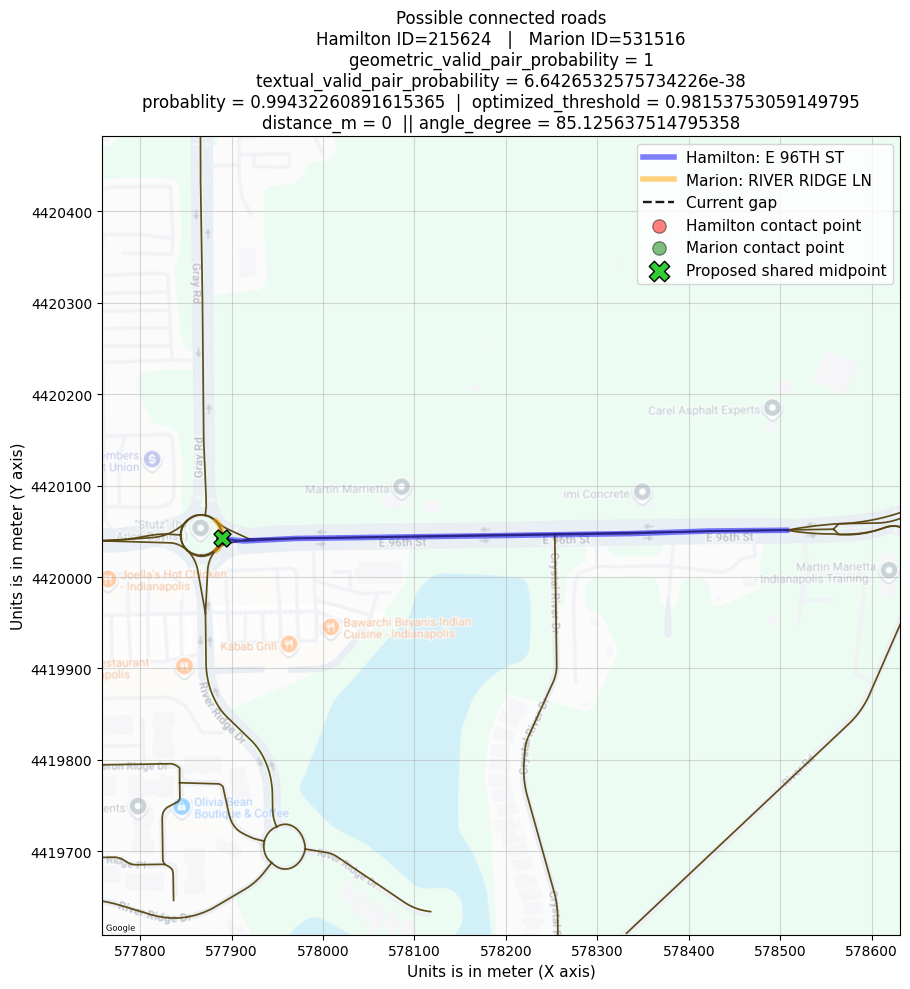

KeyboardInterrupt: Interrupted by user

In [25]:
manual_labels_section_24_df = (
    label_section_24_next_batch(
        # Automatically selects the next incomplete batch.
        batch_number=None,
        clear_each_pair=True,
        auto_finalize_when_complete=True,
    )
)

## Completion behavior

- The notebook always selects at least 2% and at most 30% of all unique candidate pairs for manual verification, except a tiny candidate set where integer rounding makes both percentages impossible.
- Manual review now uses the same synchronous, blocking `input()` procedure as notebook #6, so it does not depend on the Colab `ipywidgets` frontend.
- Use `Y`/`yes` to merge, `N`/`no` to reject, or `Q` to pause the batch.
- Progress is saved persistently in Google Drive after every answer.
- Manual review is split into batches of at most 30.
- After the final selected pair is answered, one-to-one conflicts are resolved, accepted roads are joined at an exact shared midpoint, and both updated GeoJSON files are saved to Google Drive and downloaded.
